# **Librerias**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency

from sklearn.preprocessing import PowerTransformer

from sklearn.feature_selection import mutual_info_regression
import calendar


# **Lectura de los datos y Unión de DataFrames**

Primero de todo, leemos los .csv para poder trabajar con ellos en dataframes.

In [2]:
df_stores = pd.read_csv("../data/raw/stores.csv")
df_holidays = pd.read_csv("../data/raw/holidays_events.csv")
df_oil = pd.read_csv("../data/raw/oil.csv")
df_transactions = pd.read_csv("../data/raw/transactions.csv")
df_train= pd.read_csv("../data/raw/train.csv")

A continuación, leemos uno a uno, con el fin de poder saber qué tipo de datos vamos a analizar y saber qué campo que relacionar entre ellas para juntar todos los .csv en un único dataframe.

In [3]:
print("-----------------")
print("Stores")
df_stores.info()
df_stores.head()

-----------------
Stores
<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   store_nbr  54 non-null     int64
 1   city       54 non-null     str  
 2   state      54 non-null     str  
 3   type       54 non-null     str  
 4   cluster    54 non-null     int64
dtypes: int64(2), str(3)
memory usage: 2.2 KB


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [4]:
print("-----------------")
print("Holidays")
df_holidays.info()
df_holidays.head()

-----------------
Holidays
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         350 non-null    str  
 1   type         350 non-null    str  
 2   locale       350 non-null    str  
 3   locale_name  350 non-null    str  
 4   description  350 non-null    str  
 5   transferred  350 non-null    bool 
dtypes: bool(1), str(5)
memory usage: 14.1 KB


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [5]:
print("-----------------")
print("Oil")
df_oil.info()
df_oil.head()

-----------------
Oil
<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   str    
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), str(1)
memory usage: 19.2 KB


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [6]:
print("-----------------")
print("Transactions")
df_transactions.info()
df_transactions.head()

-----------------
Transactions
<class 'pandas.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          83488 non-null  str  
 1   store_nbr     83488 non-null  int64
 2   transactions  83488 non-null  int64
dtypes: int64(2), str(1)
memory usage: 1.9 MB


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [7]:
print("-----------------")
print("Train Dataset")
df_train.info()
df_train.head()


-----------------
Train Dataset
<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Procedemos con la unión de los .csv en dataframes con la función .merge, donde le pasamos como parámetro el campo a unir y el tipo de join, en nuestro caso hemos optado por el left, ya que queremos mostrar del primer dataframe (izquierda).

In [8]:
df_final = pd.merge(df_train, df_stores, on='store_nbr', how='left')

df_final = pd.merge(df_final, df_transactions, on=['date', 'store_nbr'], how='left')

df_final = pd.merge(df_final, df_oil, on='date', how='left')

df_final = pd.merge(df_final, df_holidays, on='date', how='left')



Hemos detectado que el campo 'date', no es reconocido como fecha, por lo que como primera transfromación de los datos es cambiar el campo 'date' como fecha. Además, hemos creado nuevas columnas utilizando el campo 'date' como referencia (año, mes, día de la semana y si es finde semana o no), ya que el tráfico de clientes de una tienda podría cambiar en función del día de la semana.

In [9]:
df_final['date'] = pd.to_datetime(df_final['date'])
df_final =df_final.sort_values('date').reset_index(drop=True)

En cuanto a la partición entre el df_train y el df_test, al tener datos en una serie temporal, la división de estos se lleva a cabo a través de la fecha. En donde los datos inferiores al 2017 se asignan al df_train y aquellos superiores o igual a la fecha de corte se asignan al df_test para comprobar la capacidad predictiva del modelo.

In [10]:
fecha_corte = '2017-01-01'
# idx = int(0.8 * df_final.shape[0])
# df_train = df_final.iloc[:idx, :]
# df_test = df_final.iloc[idx:, :]

df_train = df_final[df_final['date']< fecha_corte]
df_test = df_final[df_final['date'] >= fecha_corte]

df_train.to_csv("../data/raw/df_train.csv",index=False)
df_test.to_csv("../data/raw/df_test.csv",index=False)

In [11]:
#Comprobación de que la partición haya salido con éxtio
df_train['date'].min(), df_train['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2016-12-31 00:00:00'))

In [12]:
#Comprobación de que la partición haya salido con éxtio
df_test['date'].min(), df_test['date'].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

Comprobar que el peso de cada partición sea óptimo, es decir, el porcentaje de partición de los datos de la serie temporal.

In [13]:
print(f"% Train: {df_train.shape[0]/df_final.shape[0]} , % Test: {df_test.shape[0]/df_final.shape[0]}")

% Train: 0.8652275379229871 , % Test: 0.13477246207701282


# **Exploración de los datos**

Una vez obtenido el df_final, con todas las columnas en un único dataframe, vamos a observar los datos detalladamente.

In [14]:
df_train

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1194,2013-01-01,42,CELEBRATION,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,1192,2013-01-01,42,BOOKS,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,1191,2013-01-01,42,BEVERAGES,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2642701,2595184,2016-12-31,25,SCHOOL AND OFFICE SUPPLIES,0.000,0,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2642702,2595185,2016-12-31,25,SEAFOOD,29.634,1,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2642703,2595186,2016-12-31,26,AUTOMOTIVE,13.000,0,Guayaquil,Guayas,D,10,1478.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2642704,2595187,2016-12-31,26,BABY CARE,0.000,0,Guayaquil,Guayas,D,10,1478.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False


En primer lugar, detectamos que hay nombres que cuestan entenderlos, por lo que vamos a cambiar el nombre de estas y asi facilitar a la hora de analizarlos. Tanto en el df_train como el df_test.

In [15]:
df_train.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)
df_test.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)

Ahora una vez, renombrado las columnas, vamos a comprobar que los tipos de las variables son correctos. En nuestro caso, hemos visto que hay variables que deberían tratarse como categóricas, en cambio en el dataframe inicial se detectan como numéricas.

In [16]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2642706 entries, 0 to 2642705
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[us]
 2   store_nbr     int64         
 3   family        str           
 4   sales         float64       
 5   onpromotion   int64         
 6   city          str           
 7   state         str           
 8   type_store    str           
 9   cluster       int64         
 10  transactions  float64       
 11  oil_price     float64       
 12  type_holiday  str           
 13  locale        str           
 14  locale_name   str           
 15  description   str           
 16  transferred   object        
dtypes: datetime64[us](1), float64(3), int64(4), object(1), str(8)
memory usage: 342.8+ MB


In [17]:
df_train.shape

(2642706, 17)

Eliminamos las columnas 'id' y 'store_nbr' ya que son identificadores únicos, y no son relevantes para la exploración ni para el modelo

In [18]:
df_train.drop(columns = ['id','store_nbr'], inplace = True)

In [19]:
df_train['cluster']=df_train['cluster'].astype('object')



Procedemos a dividir el dataframe en un lista con las columnas categóricas y numéricas, previas a su análisis individual

In [20]:
categoric_cols = df_train.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_cols = df_train.select_dtypes(include = [np.number]).columns.tolist()

print(f"Variables categóricas {categoric_cols}")
print("--------------------------------")
print(f"Variables numéricas {numeric_cols}")

Variables categóricas ['family', 'city', 'state', 'type_store', 'cluster', 'type_holiday', 'locale', 'locale_name', 'description', 'transferred']
--------------------------------
Variables numéricas ['sales', 'onpromotion', 'transactions', 'oil_price']


C:\Users\Administrador\AppData\Local\Temp\ipykernel_29888\2124981656.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoric_cols = df_train.select_dtypes(include=['object', 'bool']).columns.tolist()


In [21]:
df_train[numeric_cols].describe(percentiles= [.25 , .5, .75, .9, .95, .99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
sales,2642706.0,339.994847,1061.583133,0.00,0.00,9.00,185.0,822.00,1852.00,5263.0,124717.00
onpromotion,2642706.0,1.963957,11.038151,0.00,0.00,0.00,0.0,2.00,8.00,49.0,741.00
transactions,2398935.0,1704.314726,972.020822,5.00,1049.00,1399.00,2103.0,3079.00,3724.00,4905.0,8359.00
oil_price,1822986.0,70.838446,26.420837,26.19,46.28,60.01,97.1,103.54,105.88,108.0,110.62


In [22]:
df_train[categoric_cols].describe(include='object').T

C:\Users\Administrador\AppData\Local\Temp\ipykernel_29888\3789910421.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train[categoric_cols].describe(include='object').T


,count,unique,top,freq
family,2642706,33,AUTOMOTIVE,80082
city,2642706,22,Quito,880902
state,2642706,16,Pichincha,929841
type_store,2642706,5,D,880902
cluster,2642706,17,3,342573
type_holiday,449064,6,Holiday,265518
locale,449064,3,National,240570
locale_name,449064,24,Ecuador,240570
description,449064,100,Carnaval,14256
transferred,449064,2,False,440154


In [23]:
df_train.isnull().sum()

date                  0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type_store            0
cluster               0
transactions     243771
oil_price        819720
type_holiday    2193642
locale          2193642
locale_name     2193642
description     2193642
transferred     2193642
dtype: int64

In [24]:
nulos_por_variable = ((df_train.isnull().sum() / df_train.shape[0]) * 100).round(2)

print(nulos_por_variable)

date             0.00
family           0.00
sales            0.00
onpromotion      0.00
city             0.00
state            0.00
type_store       0.00
cluster          0.00
transactions     9.22
oil_price       31.02
type_holiday    83.01
locale          83.01
locale_name     83.01
description     83.01
transferred     83.01
dtype: float64


Al haber detectado algunas columnas, que se deberían tratar como categóricas, procedemos a hacer los cambios. La principal razón por la que se deben tratar como categórica y no como numérica es porque al ser variables de identificación queremos que se traten de manera equitativa.

In [25]:
df_train = df_train.astype({'transferred': 'bool'})
df_test = df_test.astype({'transferred': 'bool'})

# **Análisis Univariable**

## **1. Columnas numéricas**

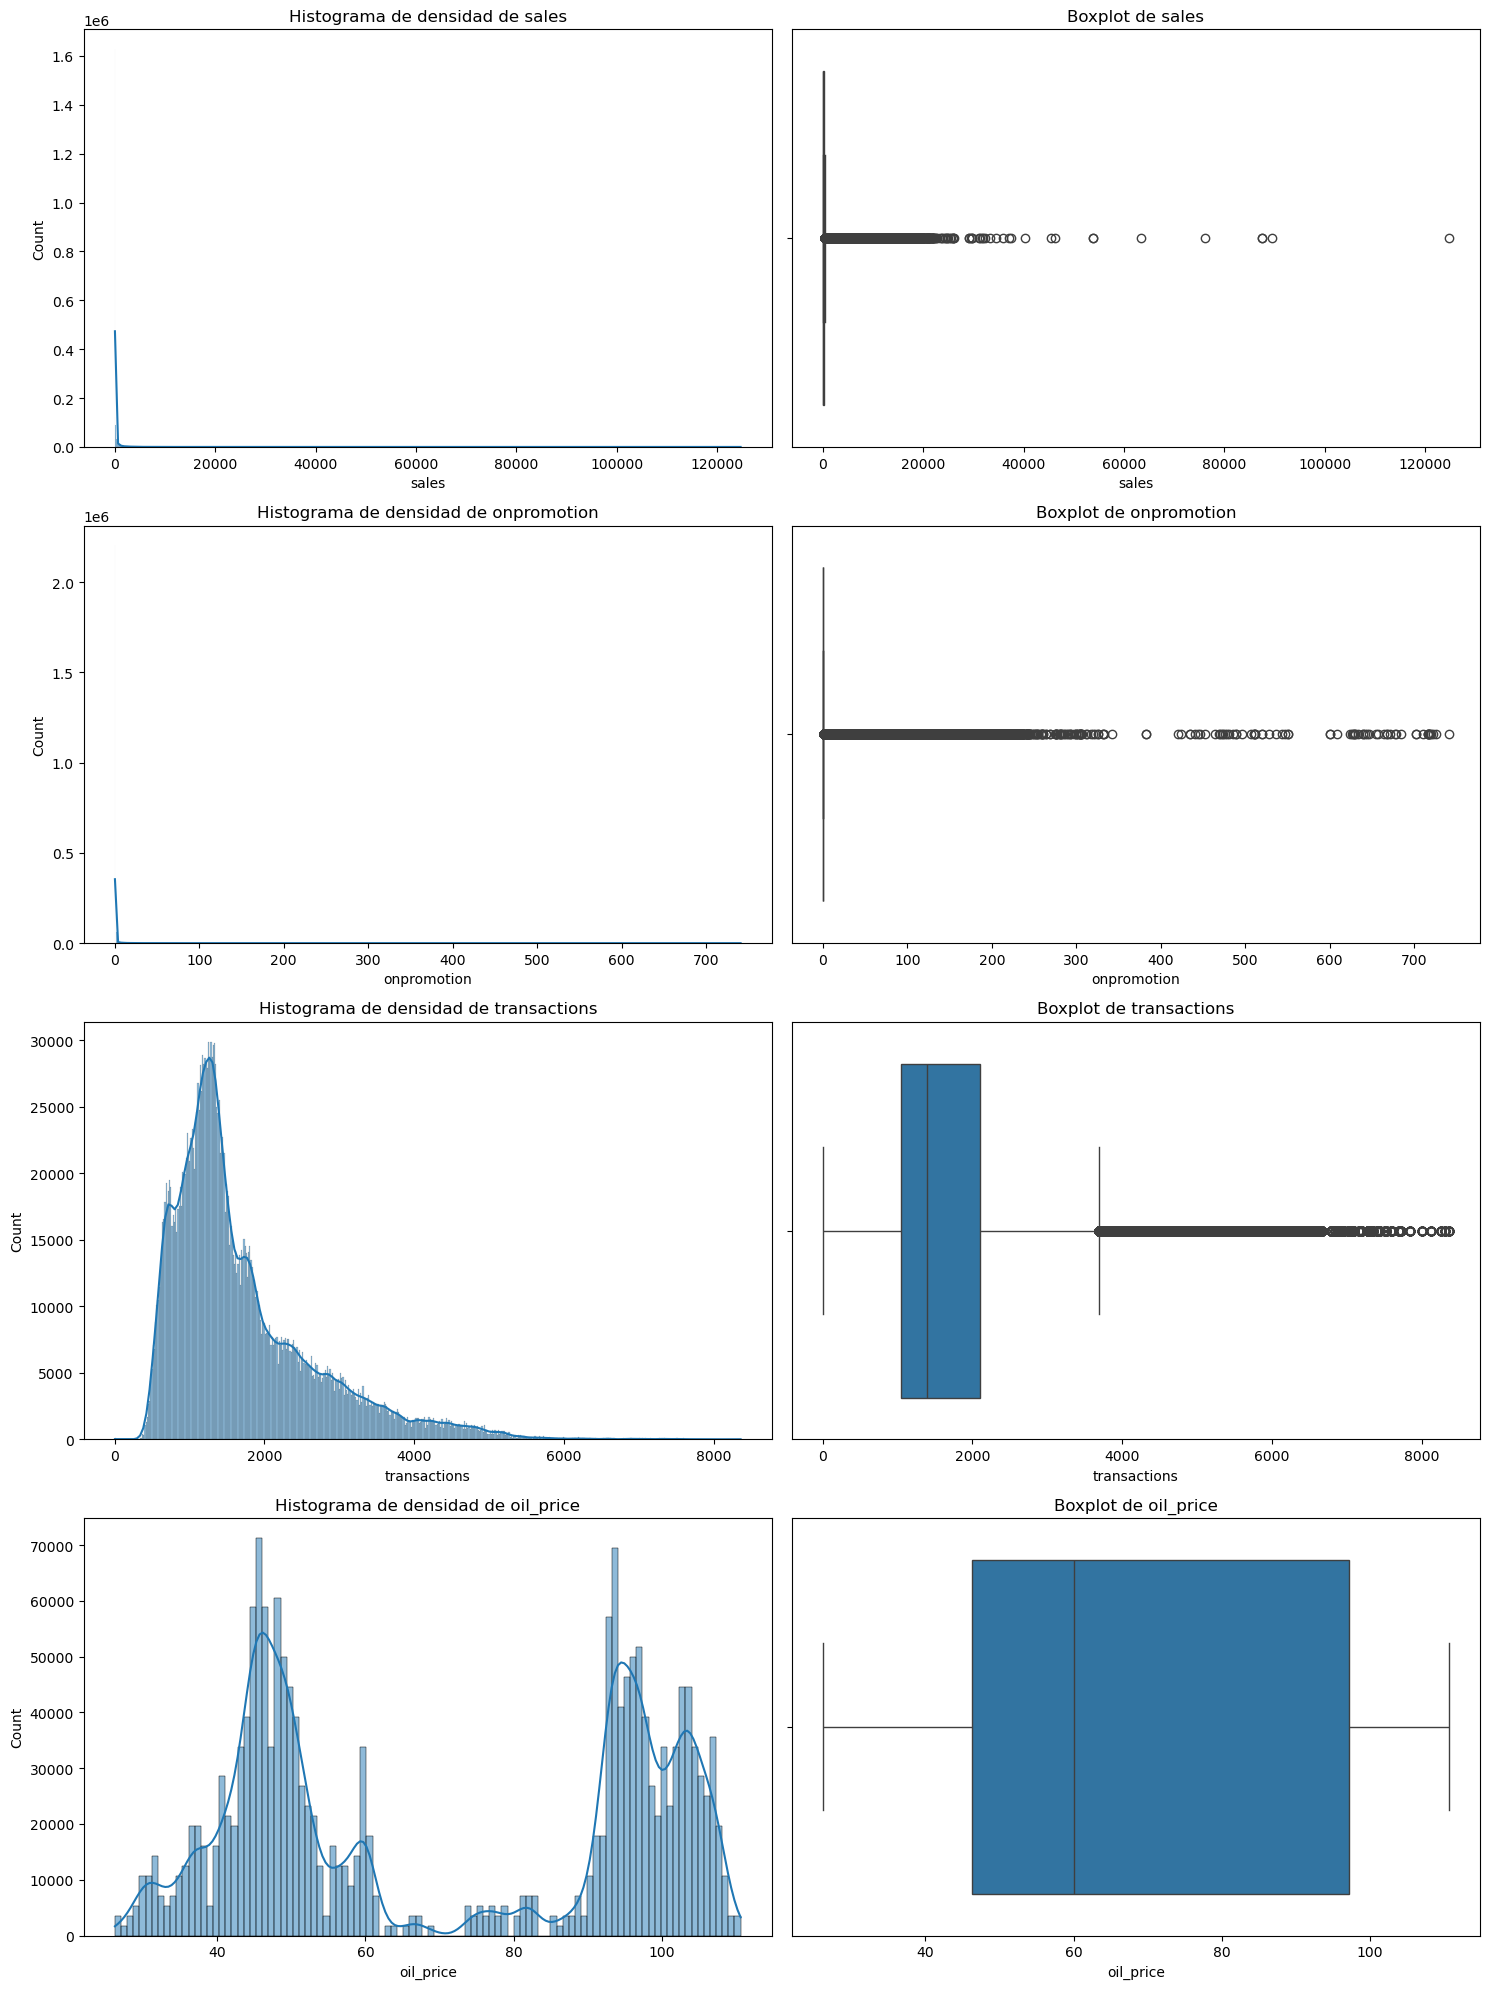

In [26]:
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(15, 5 * len(numeric_cols)))

for i, column in enumerate(df_train[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df_train[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df_train[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

In [27]:
print("--- Resumen de Outliers ---")
for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_train[(df_train[col] < lower_bound) | (df_train[col] > upper_bound)]
    perc = (len(outliers) / len(df_train)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

--- Resumen de Outliers ---
sales: 395096 registros (14.95%)
onpromotion: 439508 registros (16.63%)
transactions: 125301 registros (4.74%)
oil_price: 0 registros (0.00%)


## **Exploración de outliers**

Detectamos muchos outliers en las siguientes variables: 'sales', 'on_promotion' y 'transaction'. 

1. No podemos observar la distribución de la variable 'onpromotion', ya que al estar hablando de la cantidad de productos que se han comprado con promoción, es probable que las ventas que no tienen promoción (suponemos que es la gran mayoría) pueden distorsionar la distribución de la variable. Por lo que vamos a filtrarlo 'onpromotion'>1.
2. Observamos que la variable 'sales', tiene muchísimos outliers (14,95%) por lo que hemos planteado en implementar un logaritmo para poder apreciar la distribución y reducir el impacto de los outliers.
3. Para la variable 'transaction', vamos a implementar el Yeo Johnson para normalizar la distribución.

**Histograma y Boxplot de Sales**

Vamos a imputarle un logaritmo como hemos dicho previamente.

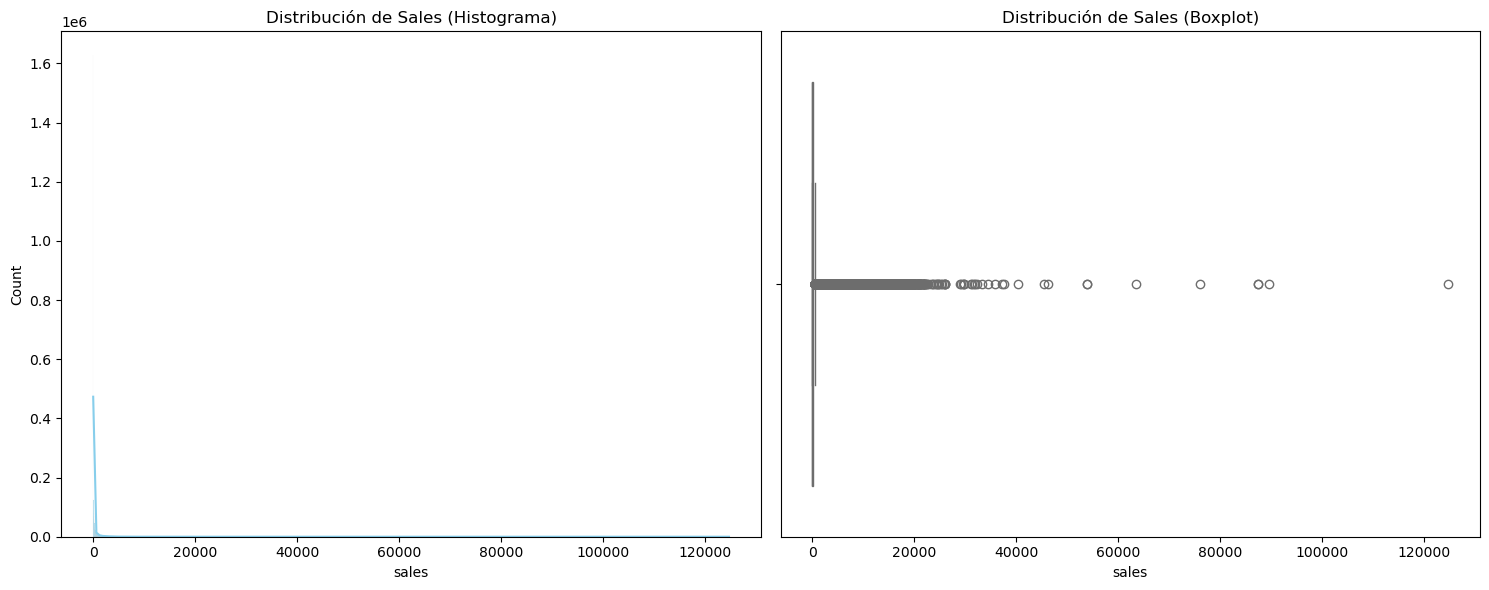

In [28]:
# Definimos 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# 1. Histograma - Se asigna al eje axes[0]
sns.histplot(df_train['sales'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Sales (Histograma)')

# 2. Boxplot - Se asigna al eje axes[1]
sns.boxplot(x=df_train['sales'], color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Sales (Boxplot)')

plt.tight_layout()
plt.show()

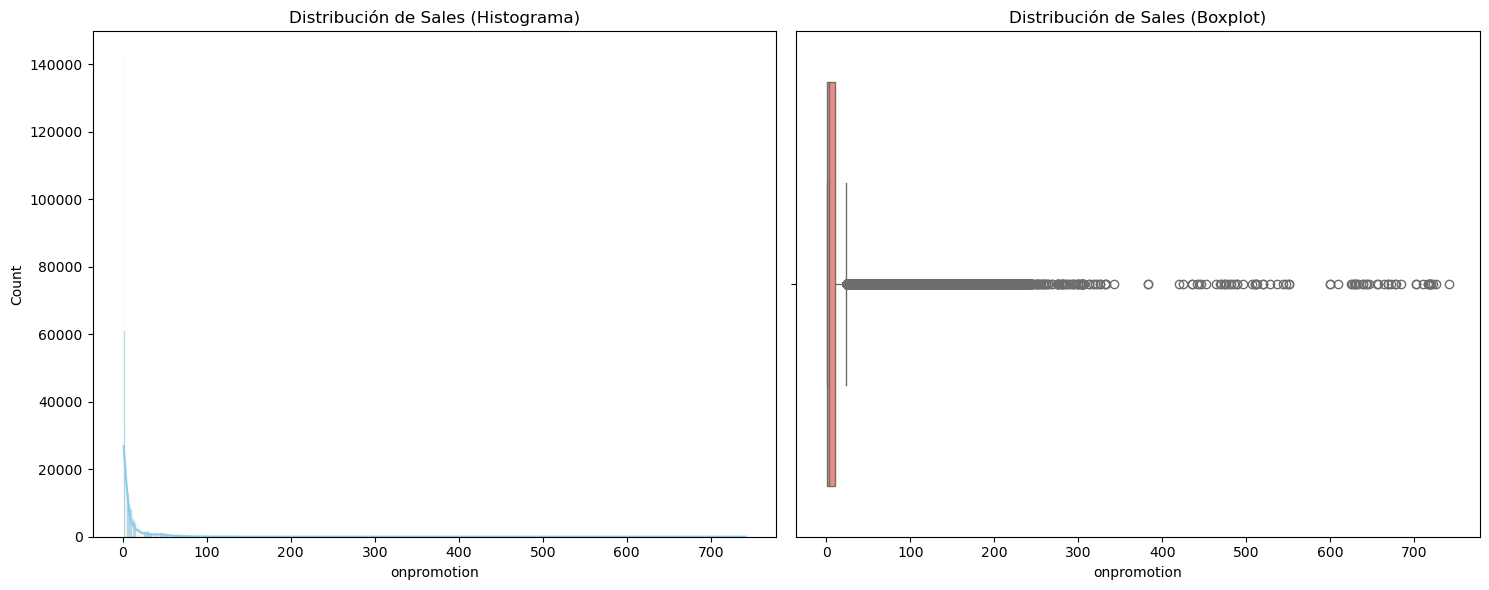

In [29]:
# 1. Filtramos los datos (solo filas donde hay promoción)
df_promote = df_train[df_train['onpromotion']>=1].copy()
# Definimos 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# 1. Histograma - Se asigna al eje axes[0]
sns.histplot(df_promote['onpromotion'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Sales (Histograma)')

# 2. Boxplot - Se asigna al eje axes[1]
sns.boxplot(x=df_promote['onpromotion'], color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Sales (Boxplot)')

plt.tight_layout()
plt.show()

**Aplicamos Logaritmos a las variables de 'onpromotion' y 'sales'**

In [30]:
log_cols = ['onpromotion','sales']

for c in log_cols:
    df_promote[c + '_log'] = np.log1p(df_promote[c])

df_promote[log_cols] = np.log1p(df_promote[log_cols])


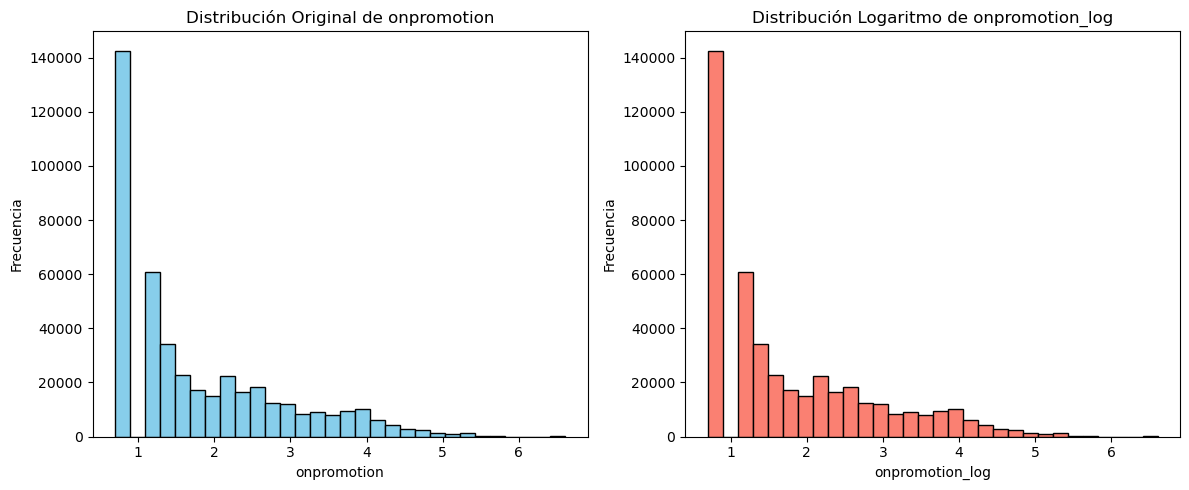

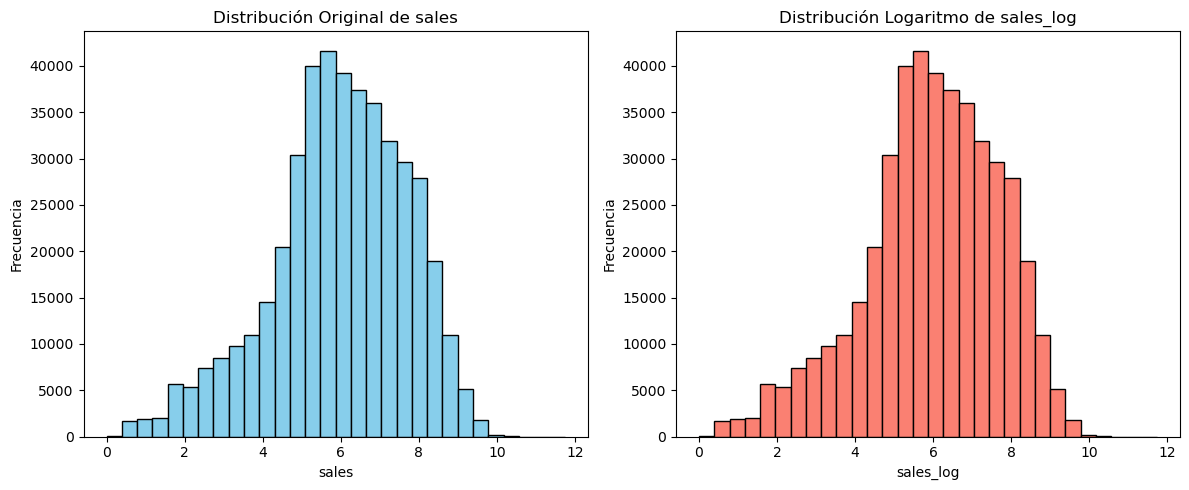

In [31]:
cols_to_plot = [
    ('onpromotion', 'onpromotion_log'),
    ('sales', 'sales_log'),
]

# Iniciamos el bucle
for col_orig, col_log in cols_to_plot:
    plt.figure(figsize=(12, 5))
    
    # 1. Histograma Original
    plt.subplot(1, 2, 1)
    plt.hist(df_promote[col_orig], bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Distribución Original de {col_orig}")
    plt.xlabel(col_orig)
    plt.ylabel("Frecuencia")
    
    # 2. Histograma Transformado
    plt.subplot(1, 2, 2)
    plt.hist(df_promote[col_log], bins=30, color="salmon", edgecolor="black")
    plt.title(f"Distribución Logaritmo de {col_log}")
    plt.xlabel(col_log)
    plt.ylabel("Frecuencia")
    
    plt.tight_layout()
    plt.show()

**Vemos el histograma y el boxplot de nuevo solamente para 'sales' y 'onpromotion'**

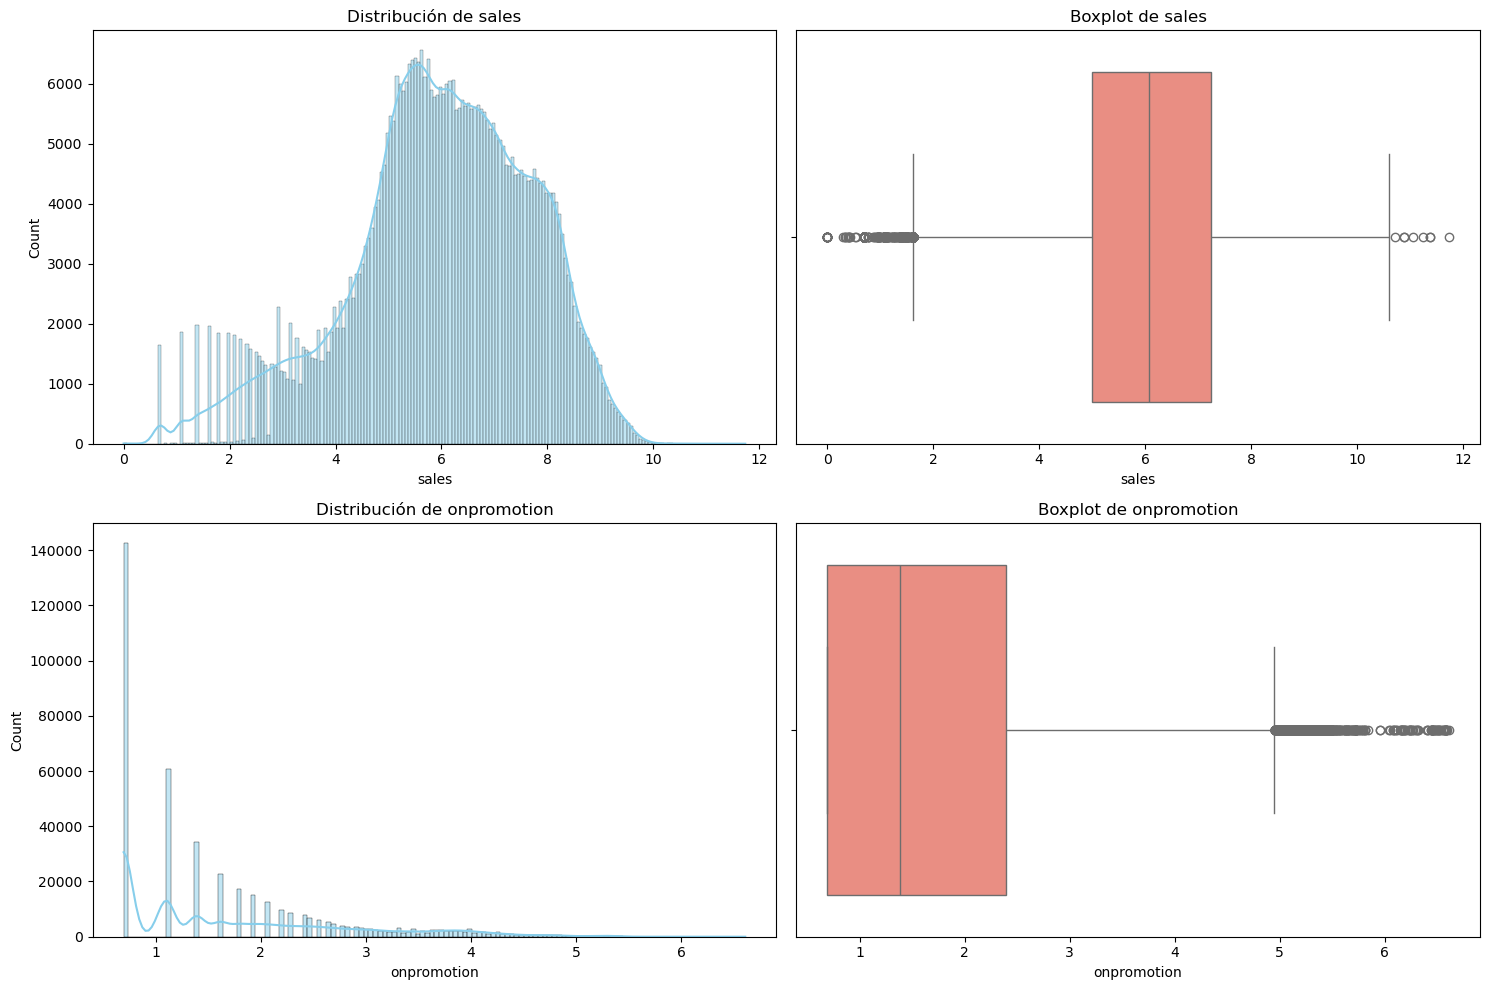

In [32]:
# 2. Definimos qué columnas queremos analizar (ejemplo: 'sales' y 'onpromotion')
columns_to_plot = ['sales', 'onpromotion'] 

# 3. Ajustamos la matriz de subplots según la cantidad de columnas
fig, axes = plt.subplots(nrows=len(columns_to_plot), ncols=2, figsize=(15, 10))

for i, col in enumerate(columns_to_plot):
    # Histograma (Columna 0 de la fila i)
    sns.histplot(df_promote[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribución de {col}')
    
    # Boxplot (Columna 1 de la fila i)
    sns.boxplot(x=df_promote[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

**Aplicamos Yeo Johnson a 'transactions' para comprobar si va a normalizar la distribución**

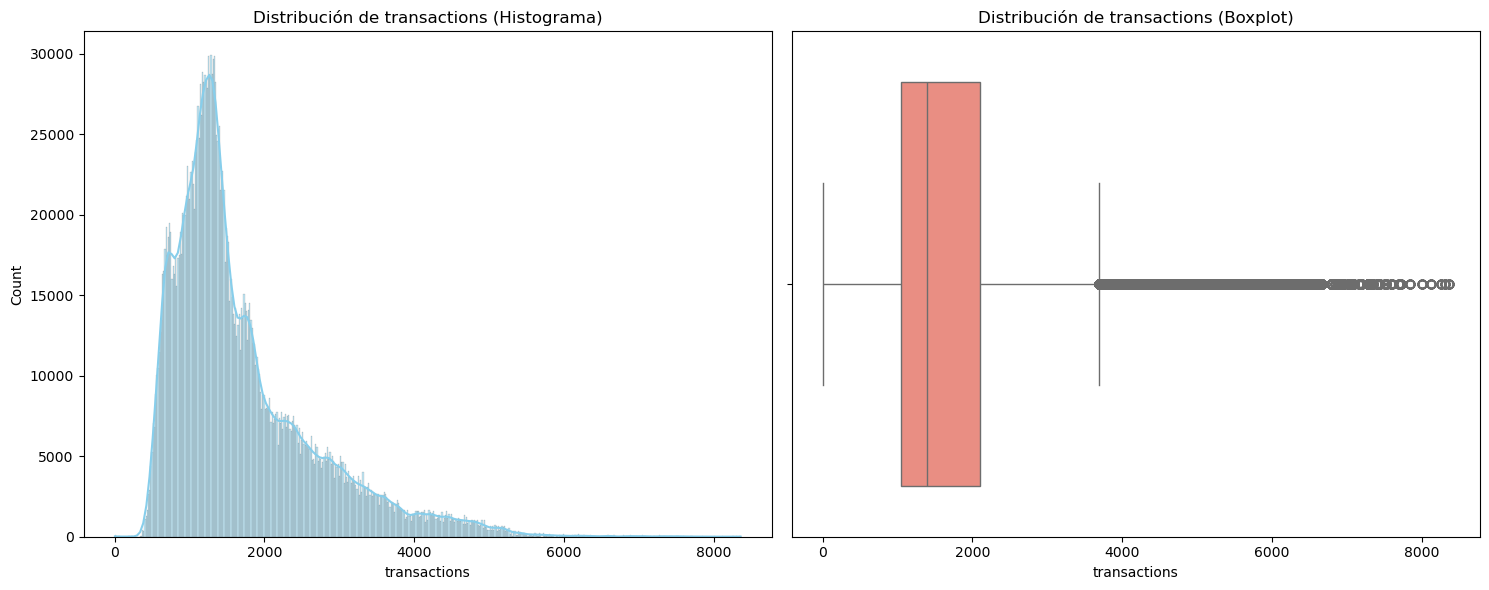

In [33]:
# Definimos 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# 1. Histograma - Se asigna al eje axes[0]
sns.histplot(df_train['transactions'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de transactions (Histograma)')

# 2. Boxplot - Se asigna al eje axes[1]
sns.boxplot(x=df_train['transactions'], color='salmon', ax=axes[1])
axes[1].set_title('Distribución de transactions (Boxplot)')

plt.tight_layout()
plt.show()

In [34]:
pt = PowerTransformer(method="yeo-johnson")
df_train['transactions_yj'] = pt.fit_transform(df_train[['transactions']])

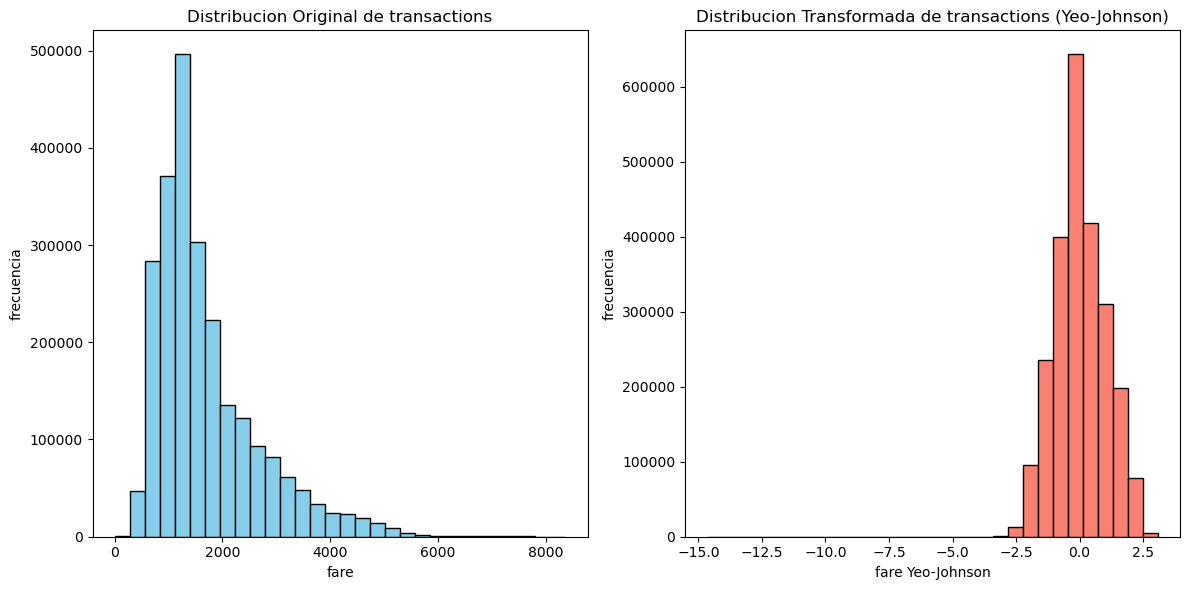

In [35]:
plt.figure(figsize=(12,6))

#histograma de la distribucion original de "transactions"
plt.subplot(1,2,1)
plt.hist(df_train["transactions"],bins=30,color="skyblue",edgecolor="k")
plt.title("Distribucion Original de transactions")
plt.xlabel("fare")
plt.ylabel("frecuencia")

#histograma de la distribucion transformada de "trasactions"
plt.subplot(1,2,2)
plt.hist(df_train["transactions_yj"],bins=30,color="salmon",edgecolor="k")
plt.title("Distribucion Transformada de transactions (Yeo-Johnson)")
plt.xlabel("fare Yeo-Johnson")
plt.ylabel("frecuencia")

plt.tight_layout()
plt.show()

Una vez aplicado el Yeo Johnson, podemos confirmar que sí que ha normalizado la distribución, vamos a comprobarlo con el histograma y el boxplot.

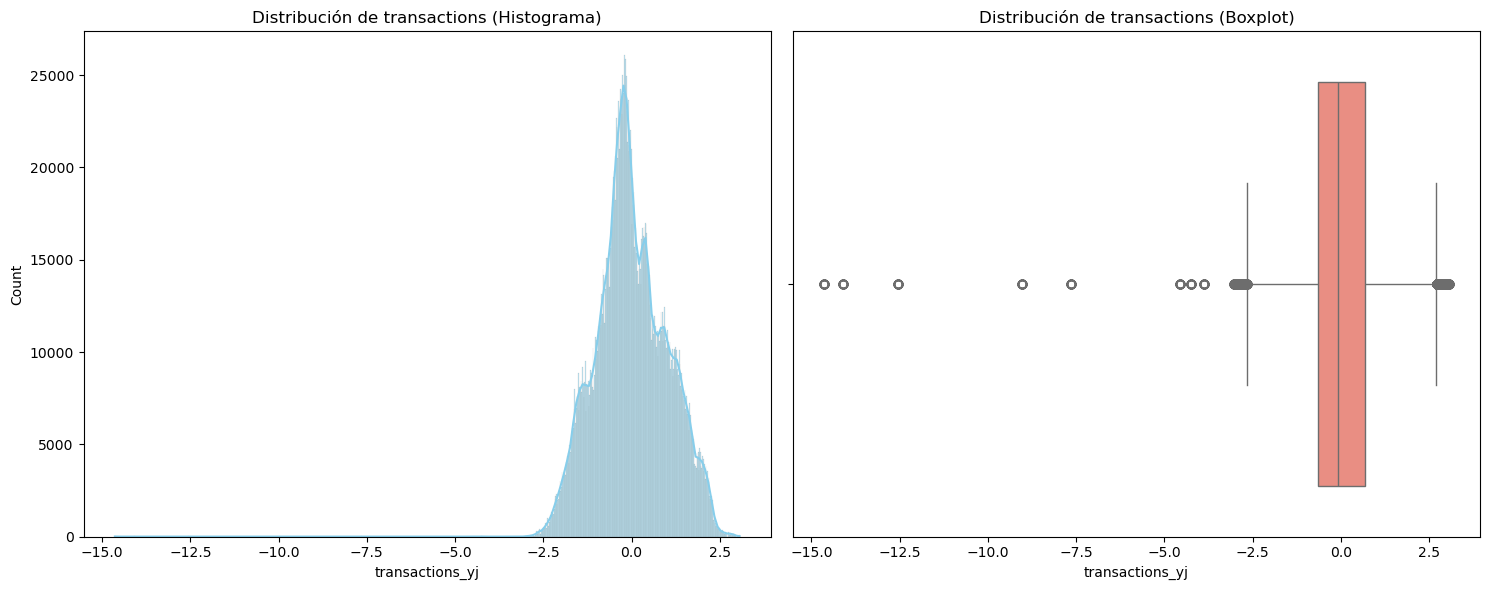

In [36]:
# Definimos 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# 1. Histograma - Se asigna al eje axes[0]
sns.histplot(df_train['transactions_yj'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de transactions (Histograma)')

# 2. Boxplot - Se asigna al eje axes[1]
sns.boxplot(x=df_train['transactions_yj'], color='salmon', ax=axes[1])
axes[1].set_title('Distribución de transactions (Boxplot)')

plt.tight_layout()
plt.show()

In [37]:
pt = PowerTransformer(method="yeo-johnson")
df_train['oil_price_yj'] = pt.fit_transform(df_train[['oil_price']])

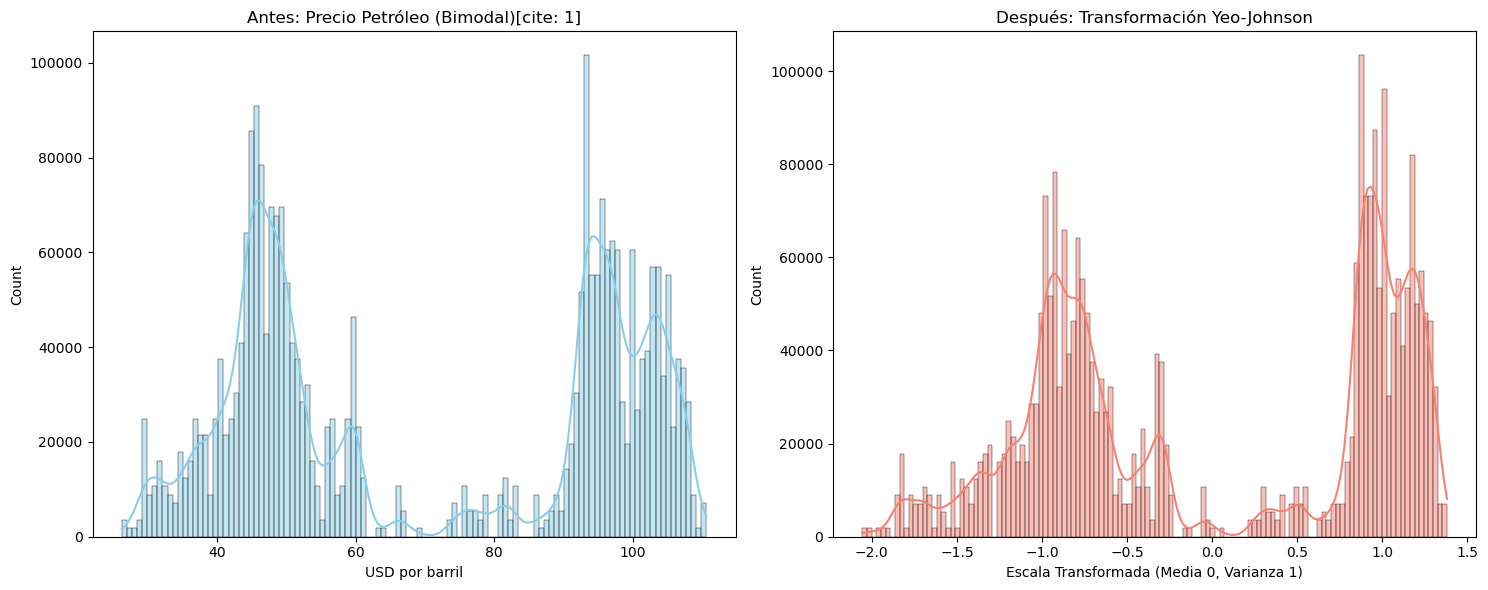

In [38]:
# 1. Preparación: Rellenar nulos (obligatorio para el transformador)
# Usamos ffill() como acordamos para mantener la continuidad económica
df_train['oil_price_filled'] = df_train['oil_price'].ffill().bfill()

# 2. Aplicar PowerTransformer (Yeo-Johnson)
pt = PowerTransformer(method="yeo-johnson")
df_train['oil_price_yj'] = pt.fit_transform(df_train[['oil_price_filled']])

# 3. Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico Izquierda: Distribución Bimodal Original
sns.histplot(df_train['oil_price_filled'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Antes: Precio Petróleo (Bimodal)[cite: 1]')
axes[0].set_xlabel('USD por barril')

# Gráfico Derecha: Distribución tras Yeo-Johnson
sns.histplot(df_train['oil_price_yj'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Después: Transformación Yeo-Johnson')
axes[1].set_xlabel('Escala Transformada (Media 0, Varianza 1)')

plt.tight_layout()
plt.show()

Vemos que si que ha surgido efecto, por lo que vamos a implementarlo en el Preprocessing.

**Cosas a implementar en el preprocessing!!!**

1. Aplicamos el logaritmo para 'onpromotion' y 'sales'
2. Aplicamos Yeo Johnson para 'transactions'

## **2. Columnas Categóricas**

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

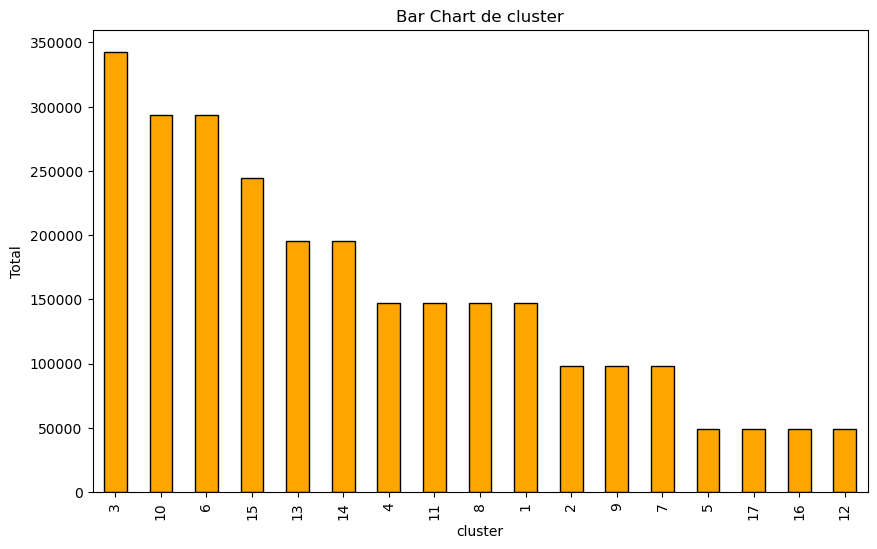

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [39]:
# Pintar la frecuencia por variable en gráfico de barras todas las columnas categóricas.
for column in df_train.columns:
    plt.figure(figsize=(10, 6))

    if isinstance(df_train[column].dtype, pd.CategoricalDtype) or df_train[column].dtype == 'object':
        df_train[column].value_counts().plot(kind='bar', color='orange', edgecolor='black')
        plt.title(f'Bar Chart de {column}')
        plt.xlabel(column)
        plt.ylabel('Total')
    
    plt.show()

In [40]:
# Iterar sobre las columnas categóricas identificadas previamente en el notebook
for col in categoric_cols:
    # nunique() cuenta los valores distintos ignorando nulos por defecto
    unique_count = df_train[col].nunique()
    print(f"Columna '{col}': {unique_count} valores únicos")

Columna 'family': 33 valores únicos
Columna 'city': 22 valores únicos
Columna 'state': 16 valores únicos
Columna 'type_store': 5 valores únicos
Columna 'cluster': 17 valores únicos
Columna 'type_holiday': 6 valores únicos
Columna 'locale': 3 valores únicos
Columna 'locale_name': 24 valores únicos
Columna 'description': 100 valores únicos
Columna 'transferred': 2 valores únicos


Observamos que la gran mayoría de las variables no tienen una cardinalidad alta, excepto para la variable 'description' (que no creemos que sea muy útil. Candidata a eliminar)

## **Análisis Bivariable**

Nuestra variable objetiva son las ventas ('sales'), por lo que vamos a realizar un Análisis Bivariable sobre cada una de las variables. Vamos a ver las siguientes gráficas:

**Variables Categóricas**

1. Ventas totales
2. Promedio de Ventas

**Variables Numéricas**

1. ScatterPlot
2. Es útil 'oil_price'?

**Variables Categóricas**

C:\Users\Administrador\AppData\Local\Temp\ipykernel_29888\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


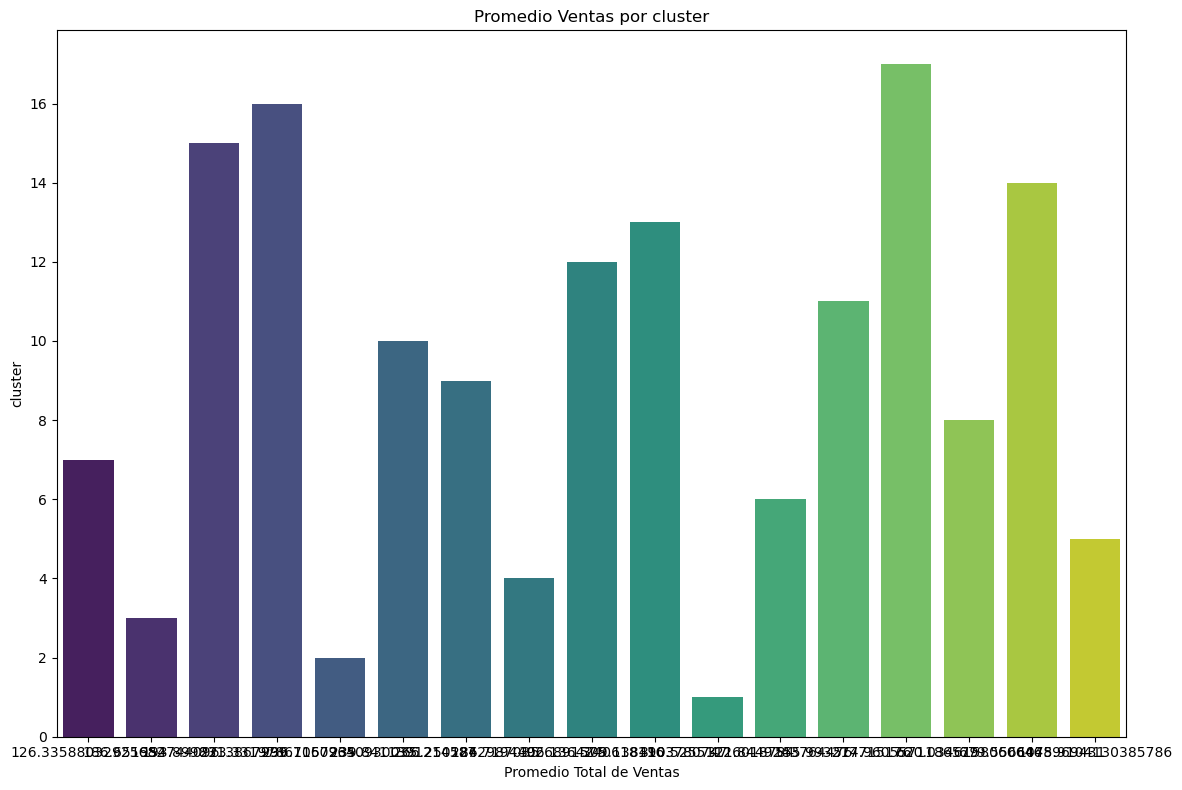

In [41]:
# Iteramos por todas las columnas del dataframe
for column in df_train.columns:
    
    # Comprobamos si la columna es categórica o tipo objeto
    if isinstance(df_train[column].dtype, pd.CategoricalDtype) or df_train[column].dtype == 'object':
        
        plt.figure(figsize=(12, 8))
        
        # 1. Agrupamos y sumamos ventas (esto hace que el gráfico cargue rápido)
        df_grouped = df_train.groupby(column)['sales'].mean().sort_values(ascending=False).reset_index()
        
        # 2. Dibujamos el gráfico de barras
        # Usamos la columna actual en el eje Y y las ventas en el eje X
        sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')
        
        # 3. Títulos y etiquetas
        plt.title(f'Promedio Ventas por {column}')
        plt.xlabel('Promedio Total de Ventas')
        plt.ylabel(column)
        
        plt.tight_layout()
        plt.show()

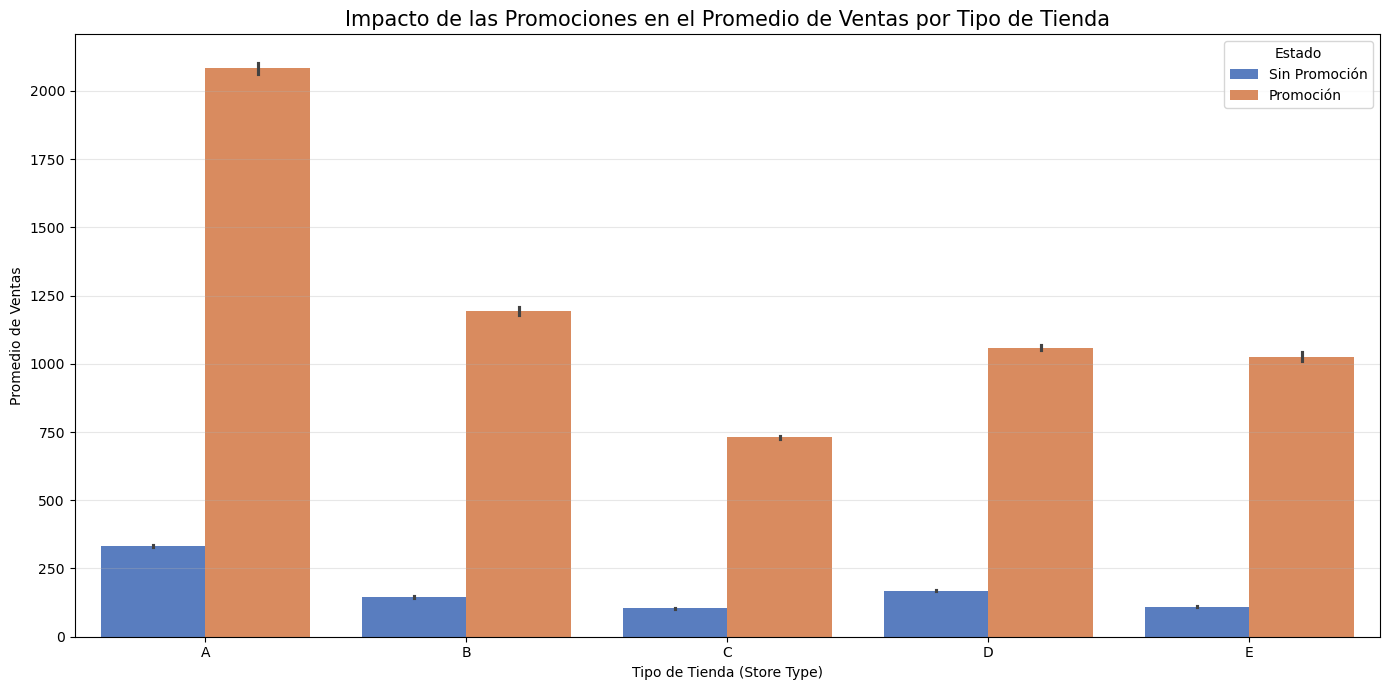

Resumen de rendimiento por tipo:
has_promo   Promoción  Sin Promoción  Incremento_%
type_store                                        
A             2082.30         331.52        528.10
B             1195.13         145.43        721.77
C              730.25         104.08        601.63
D             1059.76         168.78        527.90
E             1026.53         109.71        835.68


In [42]:


# 1. Crear una variable binaria para simplificar el análisis del impacto
# 'Si' si tiene al menos una promoción, 'No' si no tiene
df_train['has_promo'] = df_train['onpromotion'].apply(lambda x: 'Promoción' if x > 0 else 'Sin Promoción')

# 2. Configurar el gráfico comparativo
plt.figure(figsize=(14, 7))

# Usamos un gráfico de barras que compare el promedio de ventas por tipo de tienda
# segmentado por la presencia de promociones
sns.barplot(data=df_train, x='type_store', y='sales', hue='has_promo', 
            palette='muted', order=sorted(df_train['type_store'].unique()))

# 3. Personalización
plt.title('Impacto de las Promociones en el Promedio de Ventas por Tipo de Tienda', fontsize=15)
plt.xlabel('Tipo de Tienda (Store Type)')
plt.ylabel('Promedio de Ventas')
plt.legend(title='Estado')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Calcular numéricamente el "Lift" (Incremento) por tipo para tu análisis
lift_promo = df_train.groupby(['type_store', 'has_promo'])['sales'].mean().unstack()
lift_promo['Incremento_%'] = ((lift_promo['Promoción'] - lift_promo['Sin Promoción']) / lift_promo['Sin Promoción']) * 100
print("Resumen de rendimiento por tipo:")
print(lift_promo.round(2))

Podemos ver que el impacto de las promociones es significativo en todos los tipos de tienda, y podemos ver que la mayoría de las ventas provienen de productos que están en promoción. Esto nos da a ver una posible correlación entre Sales y On_promotion la cual comprobaremos más adelante.

C:\Users\Administrador\AppData\Local\Temp\ipykernel_29888\3385446175.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y='cluster', palette='viridis', orient='h')


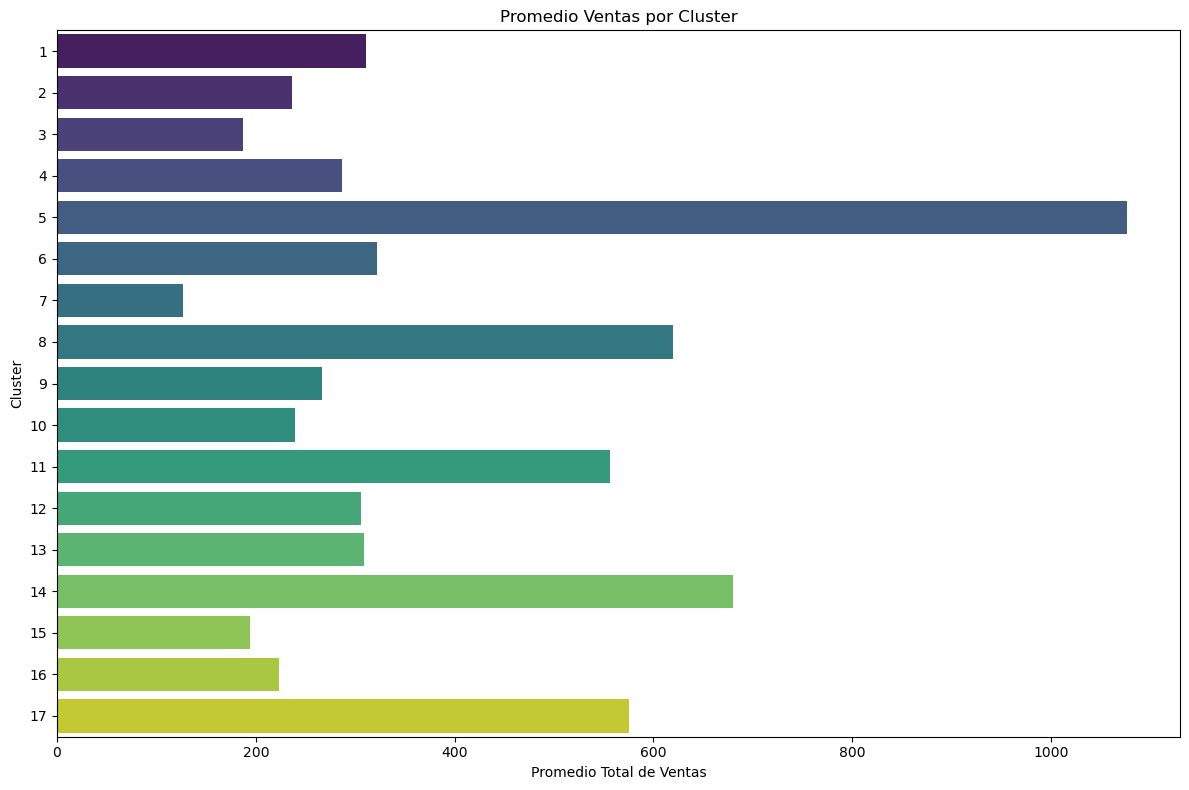

In [43]:


# Definimos el tamaño de la figura
plt.figure(figsize=(12, 8))

# 1. Agrupamos por cluster y calculamos el promedio de ventas
# Ordenamos de mayor a menor para mejor visualización
df_grouped = df_train.groupby('cluster')['sales'].mean().sort_values(ascending=False).reset_index()

# 2. Dibujamos el gráfico de barras
# Se usa el cluster en el eje Y (como variable categórica visual) y ventas en el X
sns.barplot(data=df_grouped, x='sales', y='cluster', palette='viridis', orient='h')

# 3. Títulos y etiquetas
plt.title('Promedio Ventas por Cluster')
plt.xlabel('Promedio Total de Ventas')
plt.ylabel('Cluster')

plt.tight_layout()
plt.show()

**Variables numéricas**

In [44]:
df_train[numeric_cols].dtypes

sales           float64
onpromotion       int64
transactions    float64
oil_price       float64
dtype: object

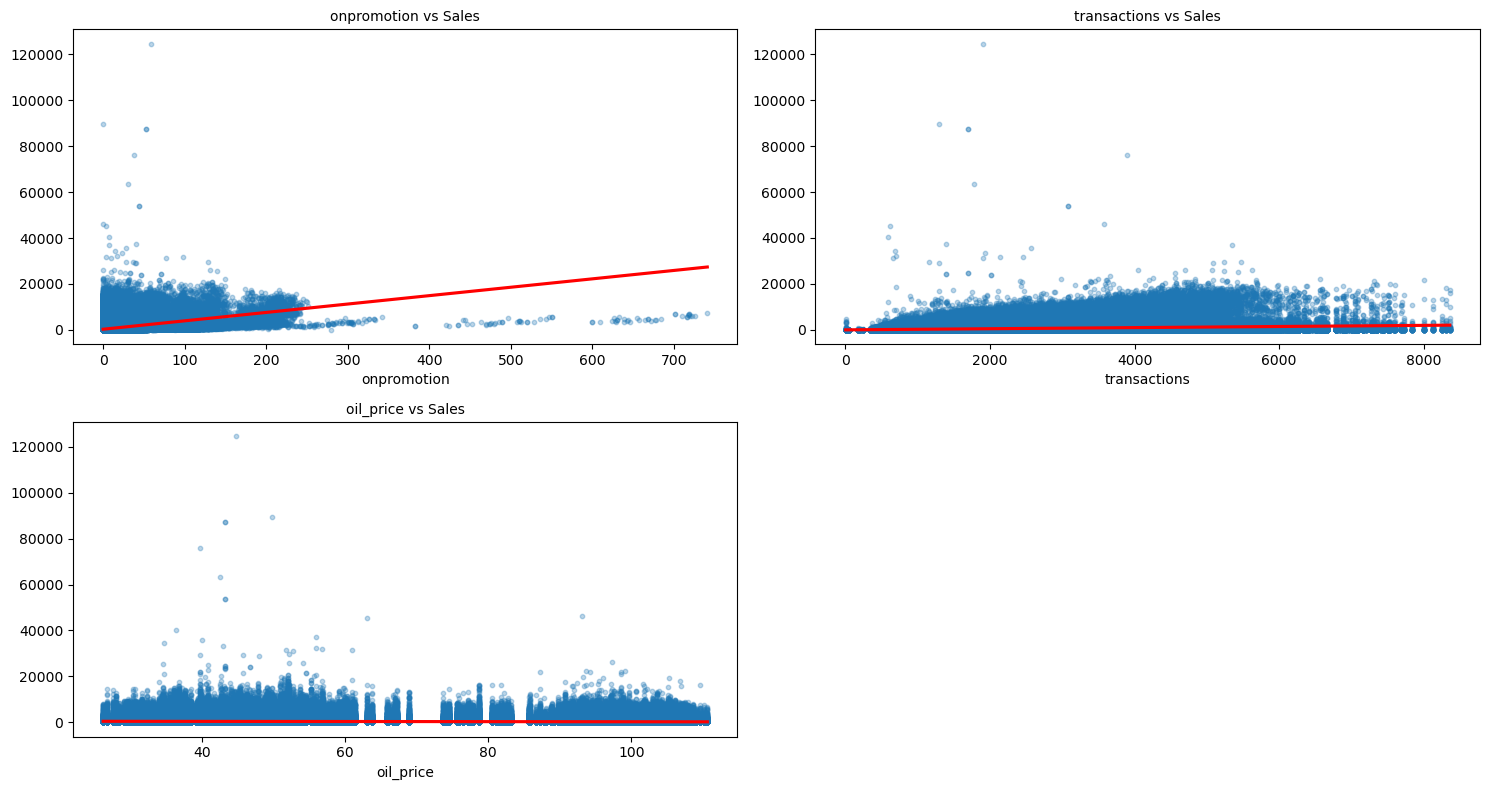

In [45]:
# 1. Filtro rápido: eliminamos 'sales' si está en la lista
cols_to_plot = [c for c in numeric_cols if c != 'sales']

n_rows = (len(cols_to_plot) + 1) // 2
fig, axs = plt.subplots(n_rows, 2, figsize=(15, 4 * n_rows))
axs = axs.flatten()

for i, col in enumerate(cols_to_plot):
    # ci=None: Desactiva el intervalo de confianza (esto ahorra el 90% del tiempo)
    # sample: Si tienes >100k filas, podrías usar data=df_train.sample(10000)
    sns.regplot(data=df_train, x=col, y='sales', ax=axs[i], 
                ci=None, 
                scatter_kws={'alpha':0.3, 's':10}, 
                line_kws={'color':'red'})
    
    axs[i].set_title(f'{col} vs Sales', fontsize=10)
    axs[i].set_ylabel('') # Menos texto, más limpio

# Limpieza de ejes vacíos
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

Podemos ver que la correlación entre el numero de ventas y los productos en promoción es moderadamente significativa. En el caso de oil_price, a priori no parece que haya correlación con las ventas, pero lo comprobaremos de forma detallada más adelante. En transactions no hay practicamente correlación (También se comprobará más adelante).

In [46]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2642706 entries, 0 to 2642705
Data columns (total 19 columns):
 #   Column            Dtype         
---  ------            -----         
 0   date              datetime64[us]
 1   family            str           
 2   sales             float64       
 3   onpromotion       int64         
 4   city              str           
 5   state             str           
 6   type_store        str           
 7   cluster           object        
 8   transactions      float64       
 9   oil_price         float64       
 10  type_holiday      str           
 11  locale            str           
 12  locale_name       str           
 13  description       str           
 14  transferred       bool          
 15  transactions_yj   float64       
 16  oil_price_yj      float64       
 17  oil_price_filled  float64       
 18  has_promo         str           
dtypes: bool(1), datetime64[us](1), float64(6), int64(1), object(1), str(9)
memory usage: 365.4+ MB


**Cómo influyen las fechas a la target?** 

Vamos a separarlo en año, mes, dia, y dias de la semana.

In [47]:
df_train_estacionalidad=df_train.copy()

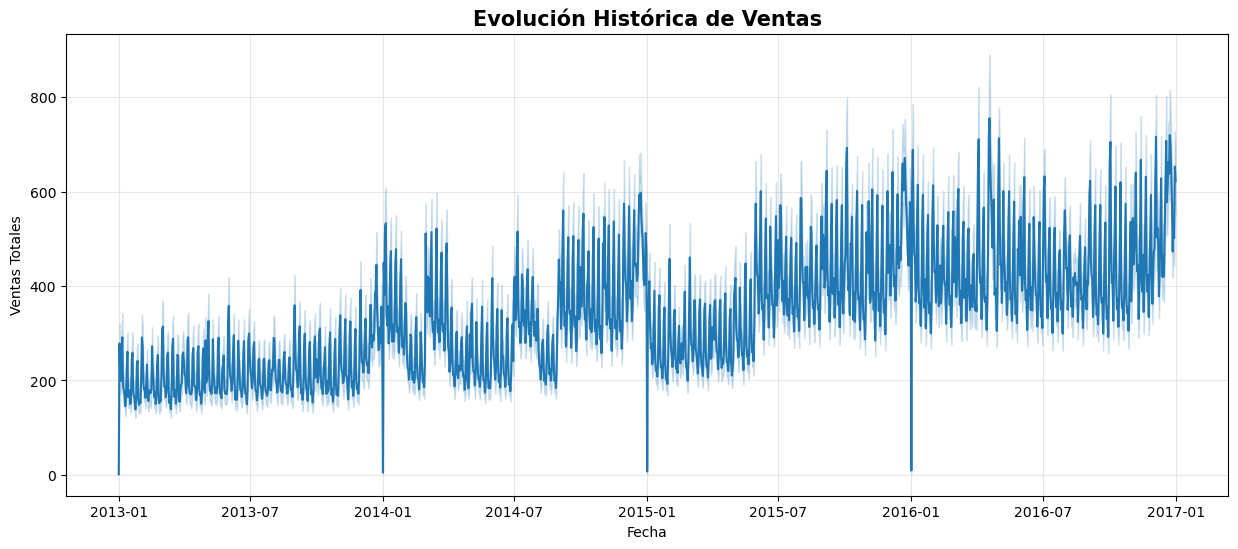

In [48]:
#GRÁFICOS PARA VER ESTACIONALIDAD
plt.figure(figsize=(15, 6))

# Gráfico de línea
sns.lineplot(data=df_train_estacionalidad, x='date', y='sales')

plt.title('Evolución Histórica de Ventas', fontsize=15, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.grid(True, alpha=0.3)
plt.show()

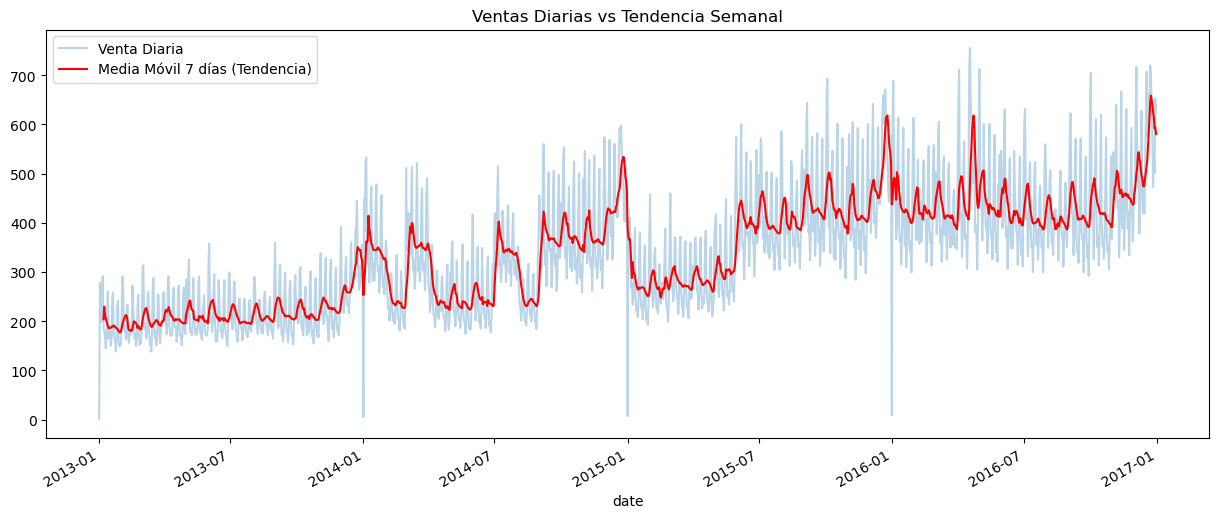

In [49]:
# Creamos una serie temporal agrupada por día (promedio de todas las tiendas/productos)
daily_sales = df_train_estacionalidad.groupby('date')['sales'].mean()

plt.figure(figsize=(15, 6))
daily_sales.plot(alpha=0.3, label='Venta Diaria')
daily_sales.rolling(window=7).mean().plot(color='red', label='Media Móvil 7 días (Tendencia)')

plt.title('Ventas Diarias vs Tendencia Semanal')
plt.legend()
plt.show()

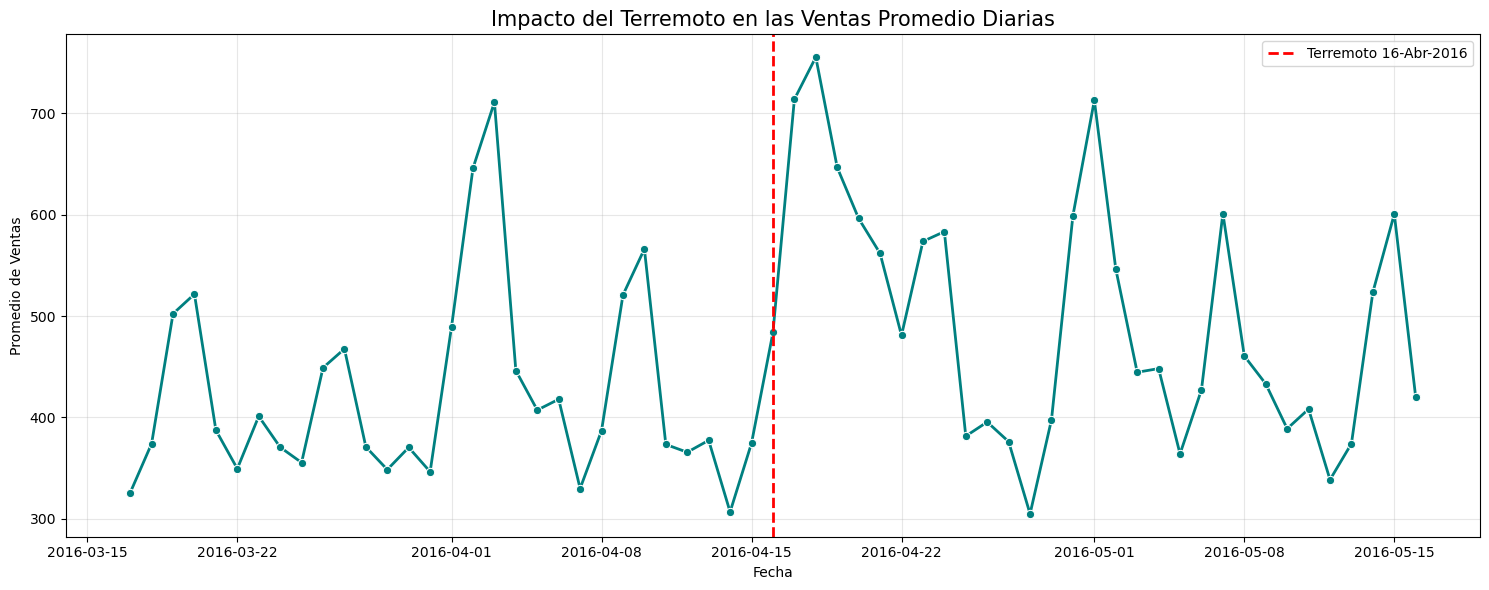

In [50]:
# 1. Definir la fecha del terremoto
fecha_terremoto = pd.to_datetime('2016-04-16')

# 2. Filtrar un rango de tiempo (ej. 30 días antes y 30 días después) 
# para que el impacto visual sea claro y no se diluya en años de datos
inicio_analisis = fecha_terremoto - pd.Timedelta(days=30)
fin_analisis = fecha_terremoto + pd.Timedelta(days=30)

df_terremoto = df_train[(df_train['date'] >= inicio_analisis) & 
                        (df_train['date'] <= fin_analisis)].copy()

# 3. Agrupar por fecha para obtener el promedio de ventas diario de todas las tiendas
sales_trend = df_terremoto.groupby('date')['sales'].mean().reset_index()

# 4. Crear el gráfico
plt.figure(figsize=(15, 6))
sns.lineplot(data=sales_trend, x='date', y='sales', marker='o', color='teal', linewidth=2)

# 5. Añadir línea vertical indicando el terremoto
plt.axvline(x=fecha_terremoto, color='red', linestyle='--', linewidth=2, label='Terremoto 16-Abr-2016')

# Personalización
plt.title('Impacto del Terremoto en las Ventas Promedio Diarias', fontsize=15)
plt.xlabel('Fecha')
plt.ylabel('Promedio de Ventas')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
df_train_estacionalidad['year'] = df_train_estacionalidad['date'].dt.year
df_train_estacionalidad['month'] = df_train_estacionalidad['date'].dt.month

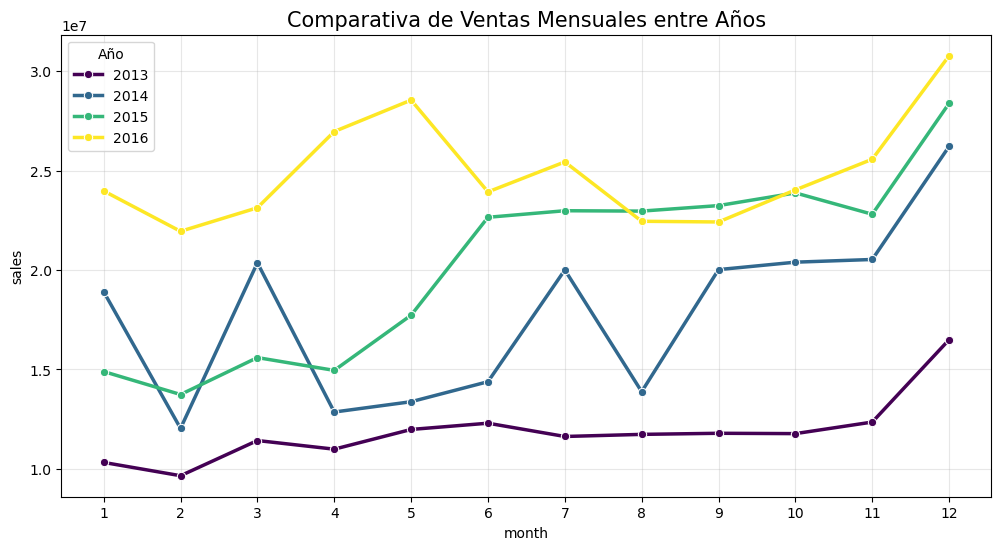

In [52]:
# 1. Agrupamos por Año y Mes
# (Asegúrate de haber ejecutado df_train['month'] = df_train['date'].dt.month)
sales_year_month = df_train_estacionalidad.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_year_month, x='month', y='sales', hue='year', 
             marker='o', palette='viridis', linewidth=2.5)

plt.title('Comparativa de Ventas Mensuales entre Años', fontsize=15)
plt.xticks(range(1, 13)) # Forzamos que salgan los 12 meses
plt.grid(True, alpha=0.3)
plt.legend(title='Año')
plt.show()

En efecto, podemos ver que despúes del terremoto hay un pico significativo de las ventas en el mes de abril, e incluso podemos ver que las ventas en abril del 2016 aumentas significativamente respecto a las ventas de los años anteriores en el mismo mes. Cabe resaltar que el número de ventas en el 2016 aumentó más de un millon significativamente respecto a los años anteriores, pero podemos confirmar que los outliers de la variable ventas vienen a raíz de esta situación. 

Como vemos que después del terremoto han habido cambios significativos, vamos a crear una columnas binaria para identificar que ventas se llevaron en vísperas del terremoto.

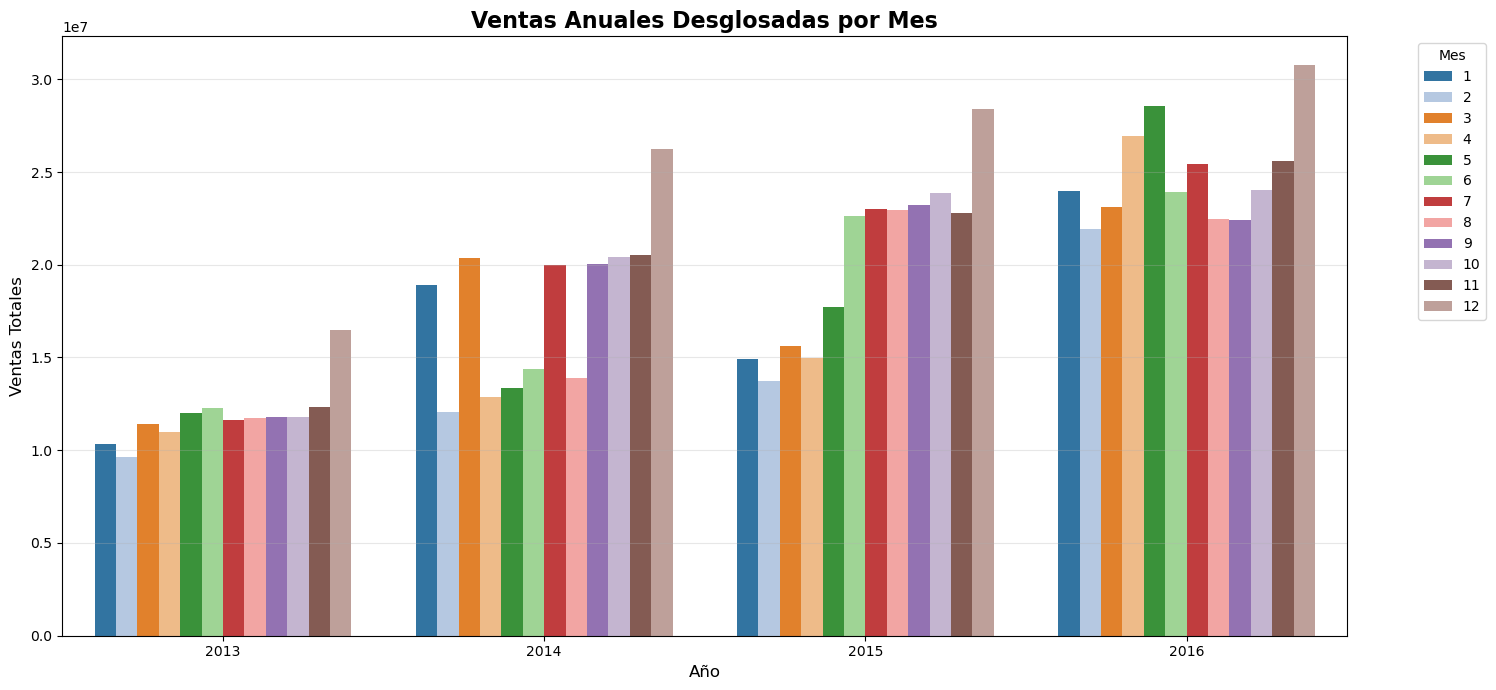

In [53]:
# 1. Aseguramos que las columnas existan
df_train_estacionalidad['year'] = df_train_estacionalidad['date'].dt.year
df_train_estacionalidad['month'] = df_train_estacionalidad['date'].dt.month

# 2. Agrupamos por Año y Mes
monthly_sales = df_train_estacionalidad.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(15, 7))

# 3. Graficamos: X es el año, el color (hue) es el mes
sns.barplot(data=monthly_sales, x='year', y='sales', hue='month', palette='tab20')

# Ajustes estéticos
plt.title('Ventas Anuales Desglosadas por Mes', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ventas Totales', fontsize=12)

# Movemos la leyenda fuera del gráfico para que no estorbe
plt.legend(title='Mes', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

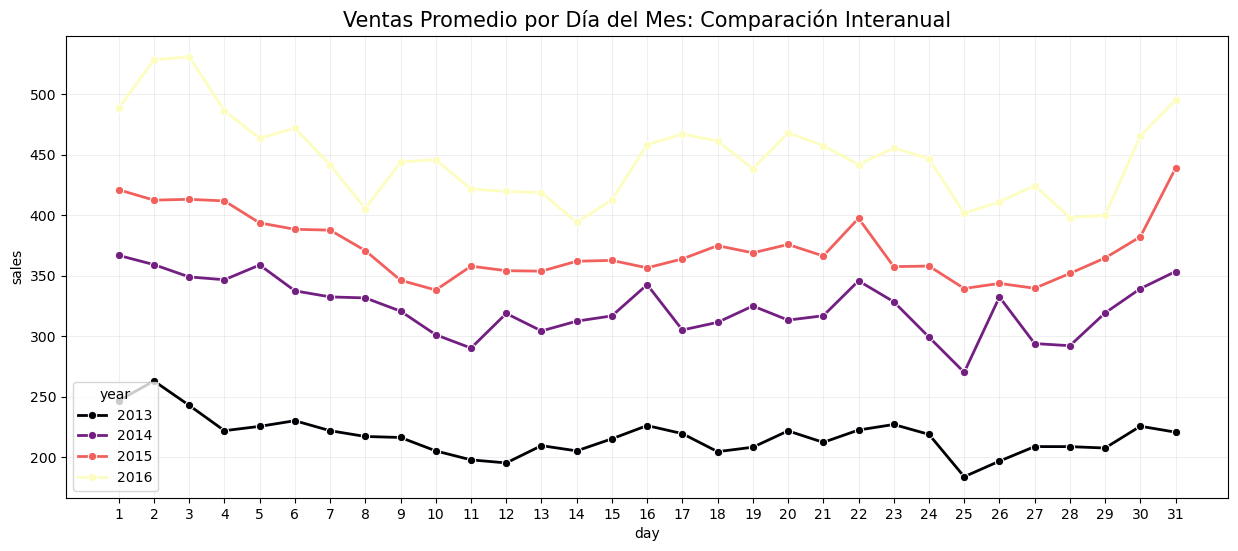

In [54]:
# 1. Agrupamos por Año y Día para tener el promedio de ventas de ese día
df_train_estacionalidad['year'] = df_train_estacionalidad['date'].dt.year
df_train_estacionalidad['day'] = df_train_estacionalidad['date'].dt.day

# 1. Agrupamos por Año y Día para tener el promedio de ventas de ese día
daily_sales_agg = df_train_estacionalidad.groupby(['year', 'day'])['sales'].mean().reset_index()

plt.figure(figsize=(15, 6))

# 2. Graficamos
sns.lineplot(data=daily_sales_agg, x='day', y='sales', hue='year', 
             marker='o', palette='magma', linewidth=2)

# Ajustamos el eje X para que muestre los 31 días
plt.xticks(range(1, 32)) 
plt.title('Ventas Promedio por Día del Mes: Comparación Interanual', fontsize=15)
plt.grid(True, alpha=0.2)
plt.show()

¿El número de ventas aumentan durante los fines de semana?

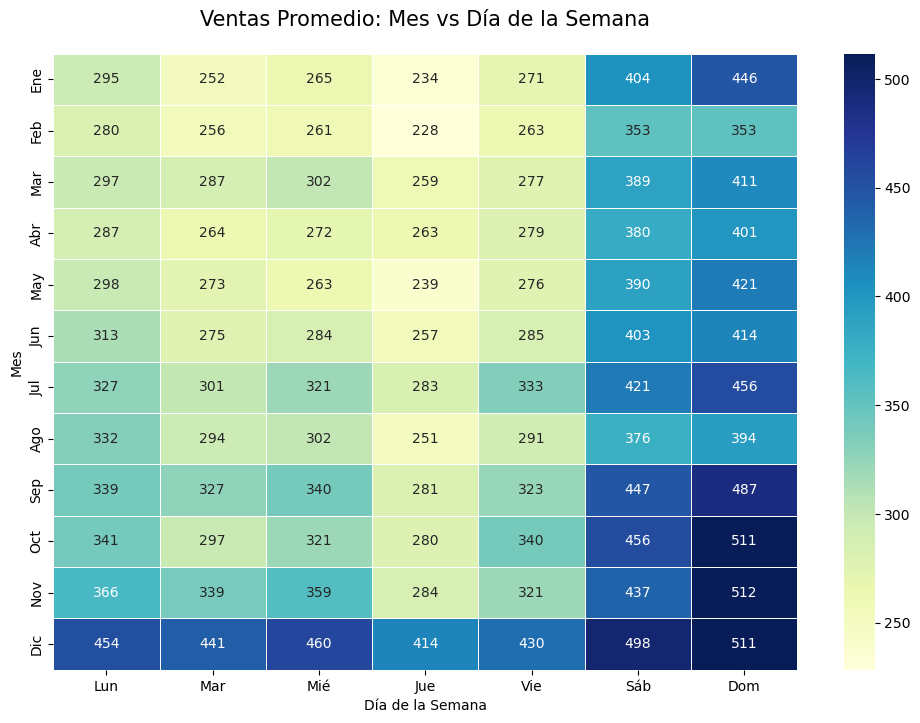

In [55]:

df_train_estacionalidad['month'] = df_train_estacionalidad['date'].dt.month
df_train_estacionalidad['day_of_week'] = df_train_estacionalidad['date'].dt.dayofweek # 0=Lunes, 6=Domingo

# 2. Agrupar y pivotar
# Calculamos la media de ventas para cada combinación de Mes y Día
heatmap_data = df_train_estacionalidad.groupby(['month', 'day_of_week'])['sales'].mean().unstack()

# 3. Renombrar ejes para que sea legible
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
heatmap_data.columns = dias
heatmap_data.index = meses

# 4. Dibujar el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True,       # Muestra los números dentro de las celdas
            fmt=".0f",        # Formato sin decimales
            cmap="YlGnBu",    # Escala de colores (Amarillo -> Verde -> Azul)
            linewidths=.5)    # Espacio entre celdas

plt.title('Ventas Promedio: Mes vs Día de la Semana', fontsize=15, pad=20)
plt.xlabel('Día de la Semana')
plt.ylabel('Mes')
plt.show()

En este gráfico podemos comprobar que en todos los meses las ventas durante los fines de semana suelen ser considerablemente mayores respecto a los días de semana.

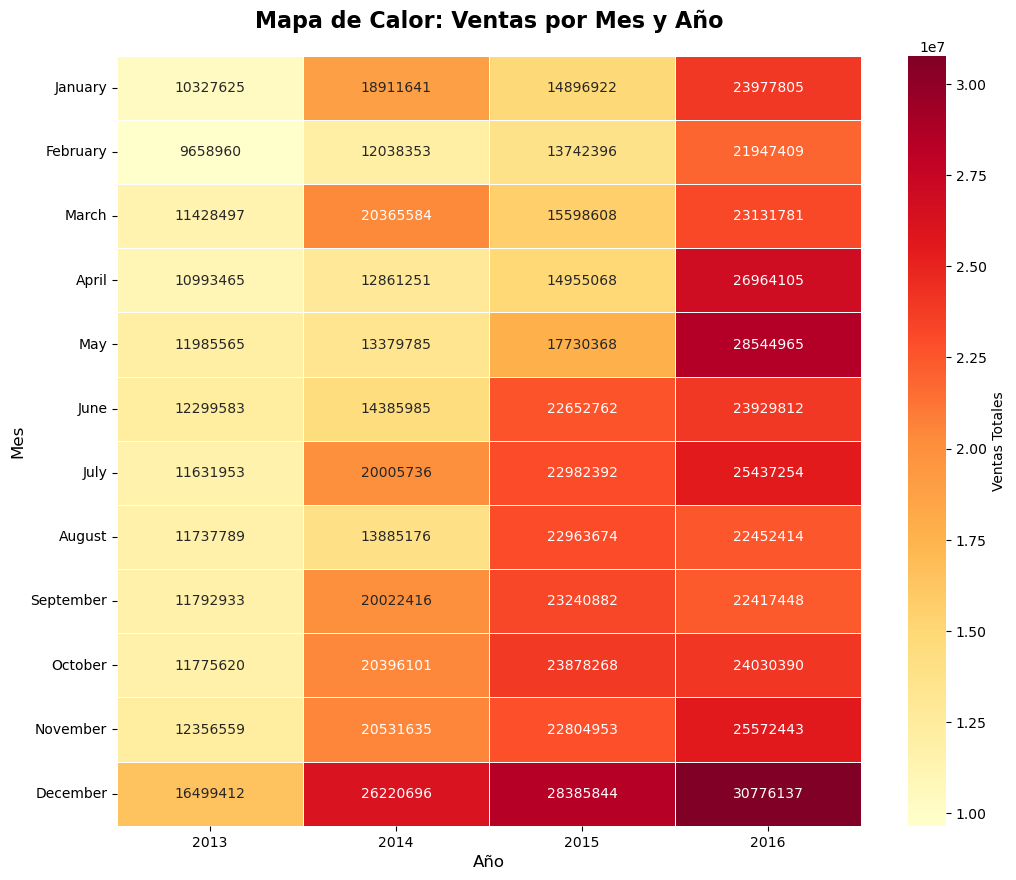

In [56]:
# 1. Preparar las columnas de tiempo
df_train_estacionalidad['year'] = df_train_estacionalidad['date'].dt.year
df_train_estacionalidad['month'] = df_train_estacionalidad['date'].dt.month

# 2. Pivotar los datos: Meses en filas, Años en columnas, Ventas como valor
# Usamos 'mean' o 'sum' según prefieras ver el promedio mensual o el total
heatmap_data = df_train_estacionalidad.pivot_table(index='month', columns='year', values='sales', aggfunc='sum')

# 3. Cambiar números de meses por nombres para mejor lectura
heatmap_data.index = [calendar.month_name[m] for m in heatmap_data.index]

# 4. Crear el Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, 
            annot=True,              # Mostrar los valores
            fmt=".0f",               # Sin decimales
            cmap="YlOrRd",           # Escala: Amarillo (bajo) -> Naranja -> Rojo (alto)
            linewidths=.5,           # Línea divisoria entre celdas
            cbar_kws={'label': 'Ventas Totales'})

plt.title('Mapa de Calor: Ventas por Mes y Año', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Mes', fontsize=12)
plt.show()

El precio de la gasolina influye?

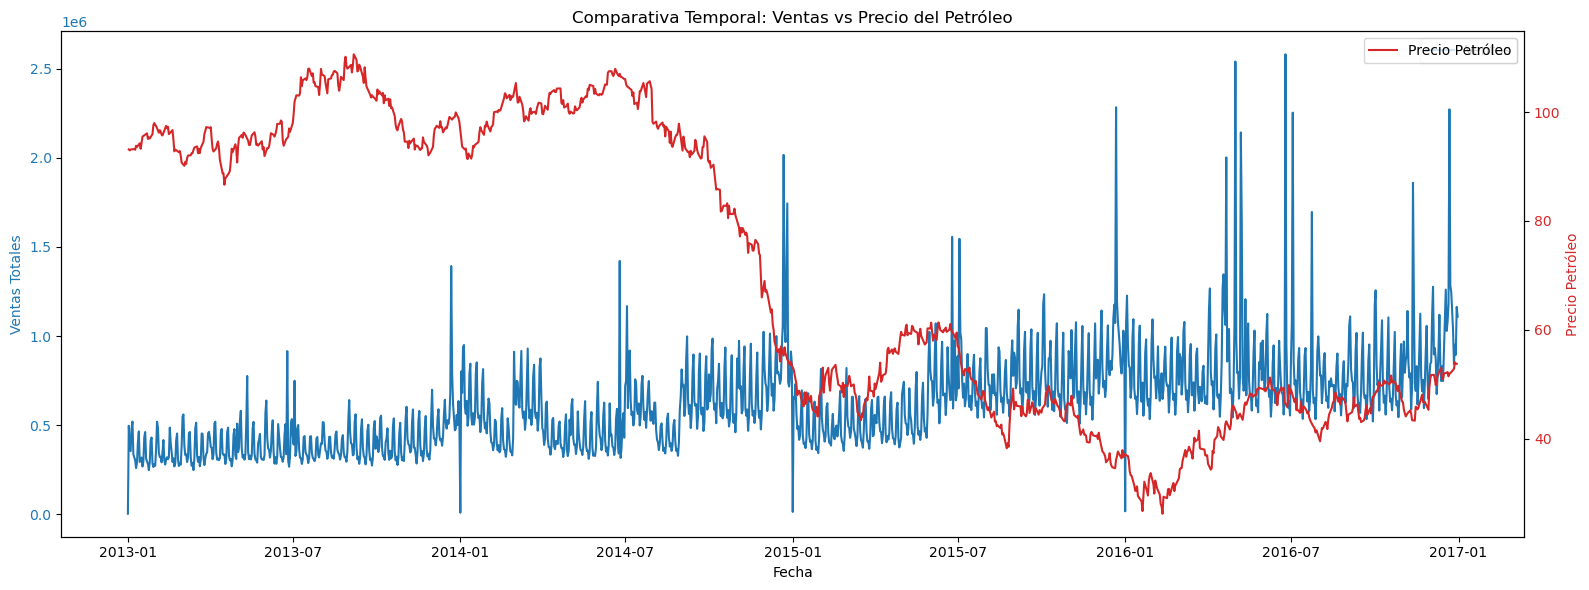

In [57]:
# 1. Agrupamos por fecha para tener una visión clara de la serie temporal
# Asumiendo que tu columna de fecha se llama 'date'
df_temp = df_train_estacionalidad.groupby('date').agg({'sales': 'sum', 'oil_price': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 6))

# --- Primer Eje: Ventas ---
color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Ventas Totales', color=color)
sns.lineplot(data=df_temp, x='date', y='sales', ax=ax1, color=color, label='Ventas')
ax1.tick_params(axis='y', labelcolor=color)

# --- Segundo Eje: Petróleo ---
ax2 = ax1.twinx() # Crea un segundo eje que comparte el mismo eje X
color = 'tab:red'
ax2.set_ylabel('Precio Petróleo', color=color)
sns.lineplot(data=df_temp, x='date', y='oil_price', ax=ax2, color=color, label='Precio Petróleo')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparativa Temporal: Ventas vs Precio del Petróleo')
fig.tight_layout()
plt.show()

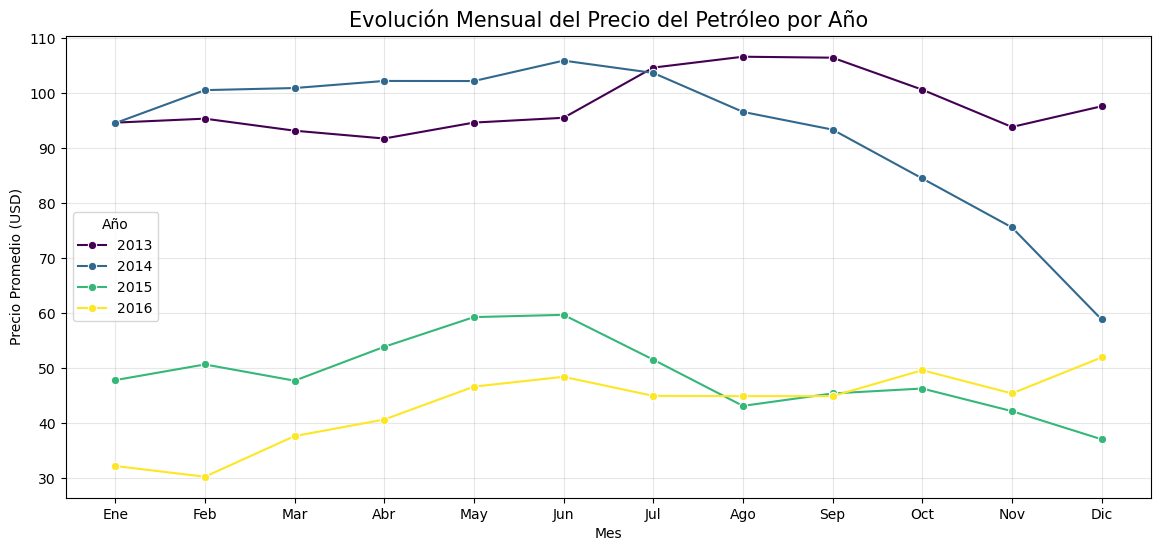

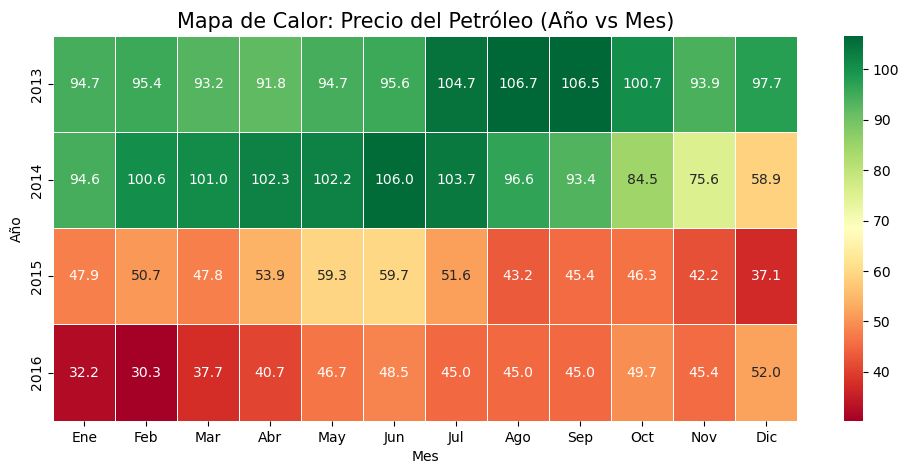

In [58]:
# 1. Preparar datos: Rellenar nulos (fines de semana/feriados) y extraer componentes
# Usamos ffill() para completar los huecos detectados en el EDA
df_oil_trend = df_train[['date', 'oil_price']].copy()
df_oil_trend['oil_price'] = df_oil_trend['oil_price'].ffill()
df_oil_trend['year'] = df_oil_trend['date'].dt.year
df_oil_trend['month'] = df_oil_trend['date'].dt.month

# 2. Agrupar por Año y Mes para obtener el promedio
oil_monthly = df_oil_trend.groupby(['year', 'month'])['oil_price'].mean().reset_index()

# 3. Gráfico de Líneas: Comparativa Anual
plt.figure(figsize=(14, 6))
sns.lineplot(data=oil_monthly, x='month', y='oil_price', hue='year', marker='o', palette='viridis')

plt.title('Evolución Mensual del Precio del Petróleo por Año', fontsize=15)
plt.xlabel('Mes')
plt.ylabel('Precio Promedio (USD)')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(True, alpha=0.3)
plt.legend(title='Año')
plt.show()

# 4. Mapa de Calor (Heatmap) para ver la intensidad de los precios
oil_pivot = oil_monthly.pivot(index="year", columns="month", values="oil_price")
oil_pivot.columns = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(12, 5))
sns.heatmap(oil_pivot, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=.5)
plt.title('Mapa de Calor: Precio del Petróleo (Año vs Mes)', fontsize=15)
plt.xlabel('Mes')
plt.ylabel('Año')
plt.show()

Podemos observar que hay una brecha enorme entre el periodo de 2013-2014 y 2015-2016. Esto lo hemos visto en la distribución en el Análisis Univariable, que no presentaba una distribución normal, sino bimodal. Por lo que no podemos explotar esta variable si seguimos asi, para ello observamos en el heatmap, que hay una diferencia entre 2014 y 2015 enorme, por lo que vamos a dividir esta variable en dos rangos de fecha (2013-14 (hasta diciembre) y 2015-16) y vemos qué pasa.

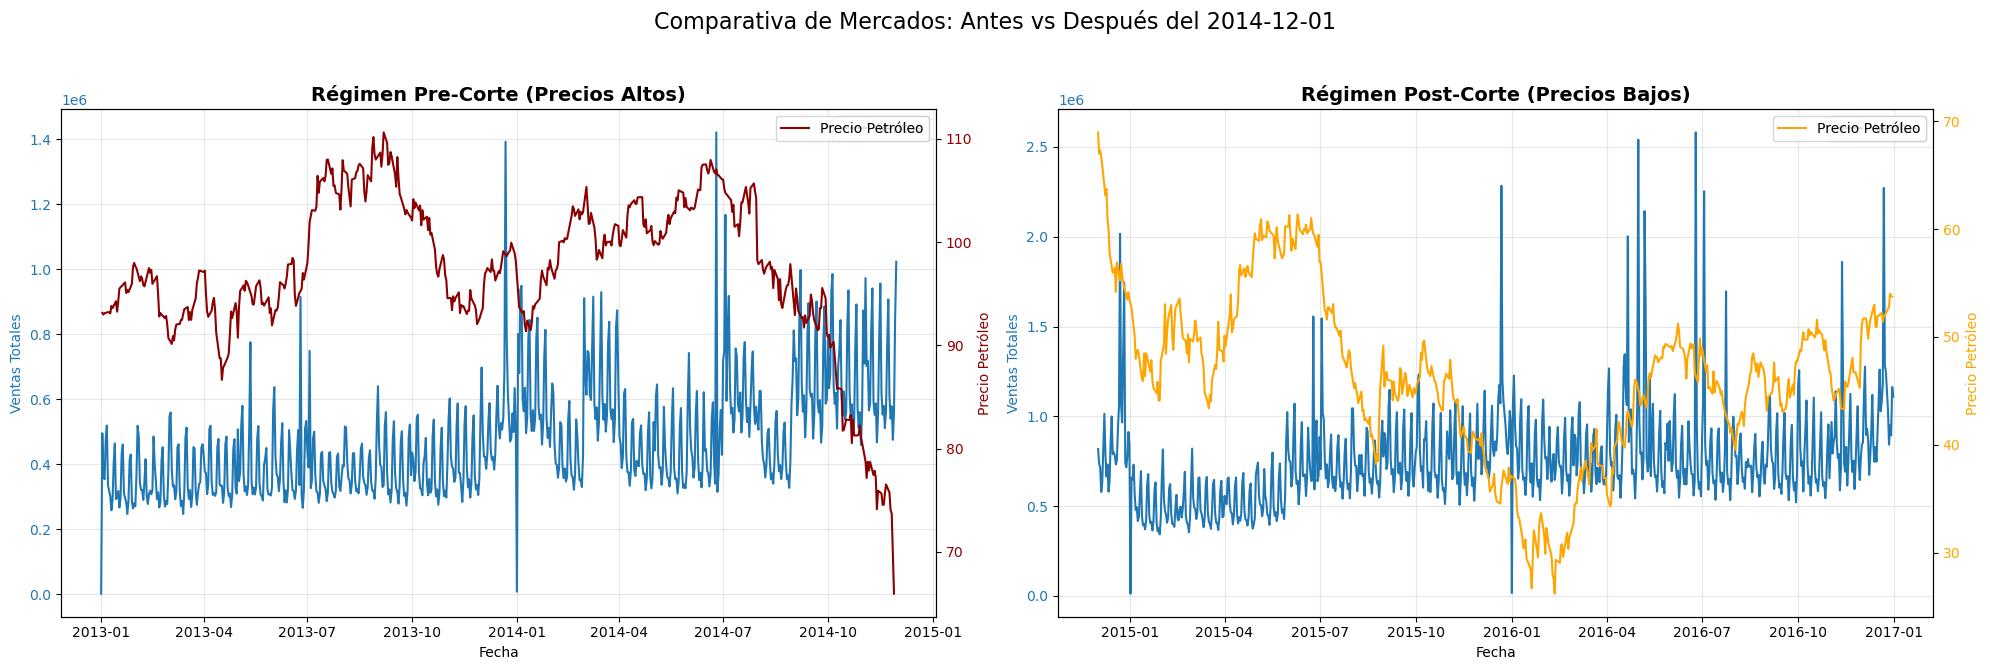

In [59]:
# 0. Preparación de datos
fecha_corte_terremoto = '2014-12-01'
df_temp = df_train_estacionalidad.groupby('date').agg({'sales': 'sum', 'oil_price': 'mean'}).reset_index()
df_temp['date'] = pd.to_datetime(df_temp['date'])
corte = pd.to_datetime(fecha_corte_terremoto)

# Separar los DataFrames
df_antes = df_temp[df_temp['date'] < corte]
df_despues = df_temp[df_temp['date'] >= corte]

# 1. Crear la figura con 1 fila y 2 columnas
fig, (ax_izq, ax_der) = plt.subplots(1, 2, figsize=(20, 7))

def plot_regimen(ax, data, titulo, color_oil):
    # Eje Ventas (Azul)
    color_sales = 'tab:blue'
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Ventas Totales', color=color_sales)
    sns.lineplot(data=data, x='date', y='sales', ax=ax, color=color_sales, label='Ventas')
    ax.tick_params(axis='y', labelcolor=color_sales)
    
    # Eje Petróleo (Variable según periodo)
    ax2 = ax.twinx()
    ax2.set_ylabel('Precio Petróleo', color=color_oil)
    sns.lineplot(data=data, x='date', y='oil_price', ax=ax2, color=color_oil, label='Precio Petróleo')
    ax2.tick_params(axis='y', labelcolor=color_oil)
    
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

# 2. Gráfica de la IZQUIERDA: Antes del corte (Precios altos)
plot_regimen(ax_izq, df_antes, 'Régimen Pre-Corte (Precios Altos)', 'darkred')

# 3. Gráfica de la DERECHA: Después del corte (Precios bajos)
plot_regimen(ax_der, df_despues, 'Régimen Post-Corte (Precios Bajos)', 'orange')

# Ajustes finales
fig.suptitle('Comparativa de Mercados: Antes vs Después del 2014-12-01', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Espacio para el título principal
plt.show()

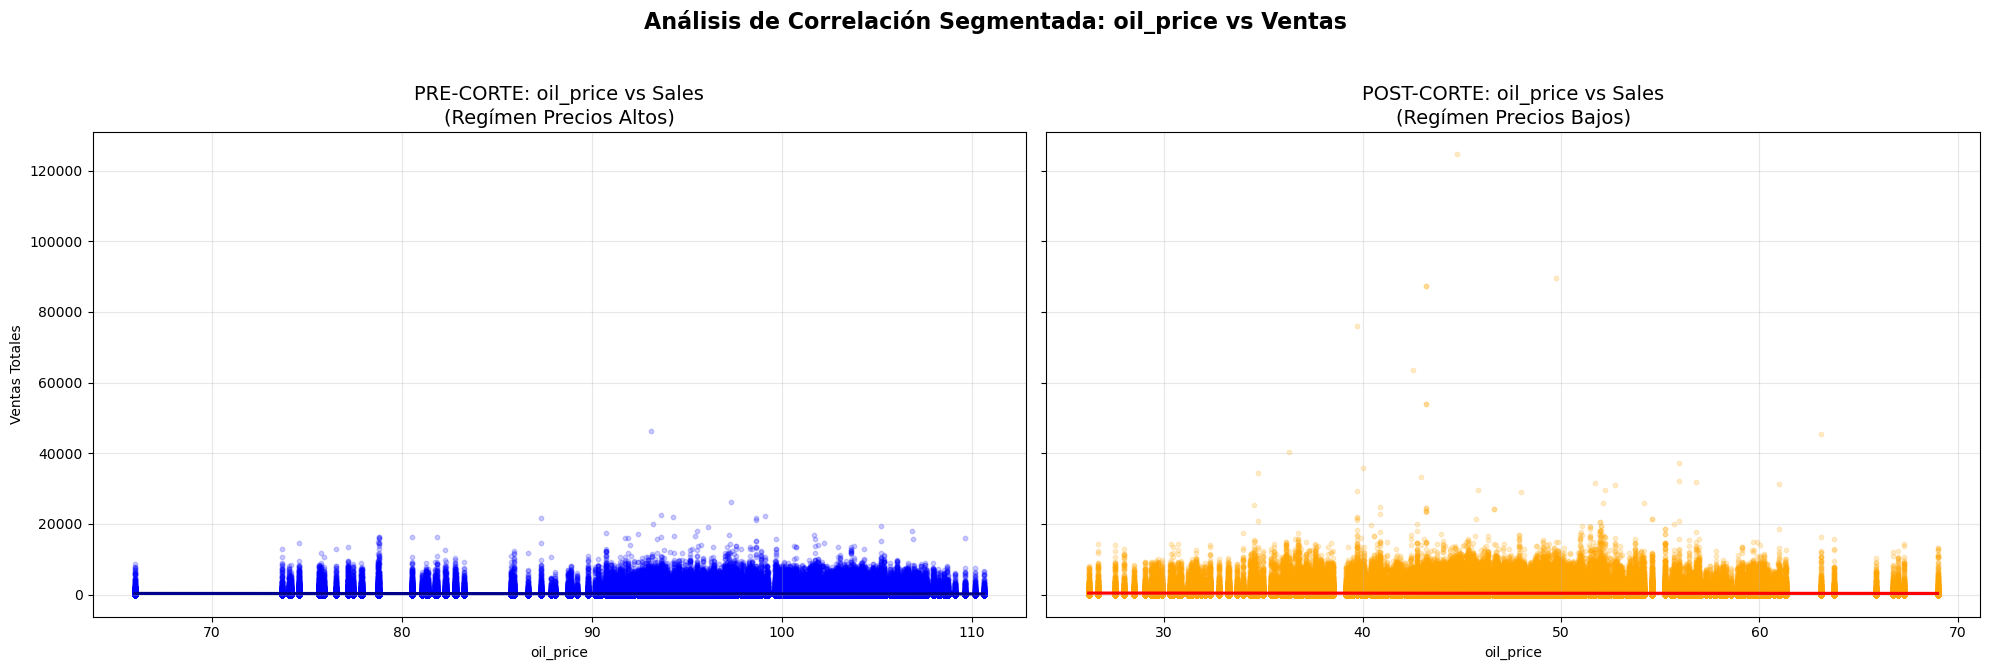

In [60]:
# 0. Preparar fechas y datos
fecha_corte = pd.to_datetime('2014-12-01')
df_train['date'] = pd.to_datetime(df_train['date'])

df_antes = df_train[df_train['date'] < fecha_corte]
df_despues = df_train[df_train['date'] >= fecha_corte]

col = 'oil_price' # La variable bimodal

# 1. Crear la figura con dos subplots (izquierda y derecha)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# --- Gráfica IZQUIERDA: Antes del corte (Precios Altos) ---
sns.regplot(data=df_antes, x=col, y='sales', ax=ax1, 
            ci=None, 
            scatter_kws={'alpha':0.2, 's':10, 'color':'blue'}, 
            line_kws={'color':'darkblue'})
ax1.set_title(f'PRE-CORTE: {col} vs Sales\n(Regímen Precios Altos)', fontsize=14)
ax1.set_ylabel('Ventas Totales')
ax1.grid(True, alpha=0.3)

# --- Gráfica DERECHA: Después del corte (Precios Bajos) ---
sns.regplot(data=df_despues, x=col, y='sales', ax=ax2, 
            ci=None, 
            scatter_kws={'alpha':0.2, 's':10, 'color':'orange'}, 
            line_kws={'color':'red'})
ax2.set_title(f'POST-CORTE: {col} vs Sales\n(Regímen Precios Bajos)', fontsize=14)
ax2.set_ylabel('') # Quitamos para no repetir ya que comparten eje Y
ax2.grid(True, alpha=0.3)

# Ajustes estéticos finales
plt.suptitle(f'Análisis de Correlación Segmentada: {col} vs Ventas', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [61]:
# 1. Asegurar formato de fecha y segmentar
df_train['date'] = pd.to_datetime(df_train['date'])
fecha_corte = '2014-12-01'

df_antes = df_train[df_train['date'] < fecha_corte]
df_despues = df_train[df_train['date'] >= fecha_corte]

# 2. Calcular correlaciones
corr_antes = df_antes['oil_price'].corr(df_antes['sales'])
corr_despues = df_despues['oil_price'].corr(df_despues['sales'])

# 3. Mostrar resultados
print(f"--- Análisis de Correlación (Oil Price vs Sales) ---")
print(f"Régimen PRE-CORTE (Precios Altos):  {corr_antes:.4f}")
print(f"Régimen POST-CORTE (Precios Bajos): {corr_despues:.4f}")
print("-" * 50)

# Interpretación rápida
diferencia = abs(corr_antes - corr_despues)
print(f"Diferencia absoluta de correlación: {diferencia:.4f}")

--- Análisis de Correlación (Oil Price vs Sales) ---
Régimen PRE-CORTE (Precios Altos):  -0.0283
Régimen POST-CORTE (Precios Bajos): -0.0168
--------------------------------------------------
Diferencia absoluta de correlación: 0.0115


## Hipótesis Negocio

1. El impacto de las promociones (‘on_promotion’)  en el volumen de ventas no es uniforme y es significativamente más alto en productos de “Larga Duración” que en “Perecederos”

In [62]:
df_train['family'].value_counts()

family
AUTOMOTIVE                    80082
CELEBRATION                   80082
BREAD/BAKERY                  80082
BOOKS                         80082
BEVERAGES                     80082
BEAUTY                        80082
BABY CARE                     80082
SEAFOOD                       80082
SCHOOL AND OFFICE SUPPLIES    80082
PRODUCE                       80082
PREPARED FOODS                80082
POULTRY                       80082
PLAYERS AND ELECTRONICS       80082
PET SUPPLIES                  80082
PERSONAL CARE                 80082
MEATS                         80082
MAGAZINES                     80082
LIQUOR,WINE,BEER              80082
LINGERIE                      80082
LAWN AND GARDEN               80082
LADIESWEAR                    80082
HOME CARE                     80082
HOME APPLIANCES               80082
CLEANING                      80082
DAIRY                         80082
DELI                          80082
EGGS                          80082
HOME AND KITCHEN II  

--- IMPACTO DE PROMOCIONES POR TIPO ---
en_oferta            False        True  multiplicador_ventas
tipo_articulo                                               
Larga Duración  130.315396  1774.93554             13.620306
Perecederos     274.735576   624.53970              2.273239


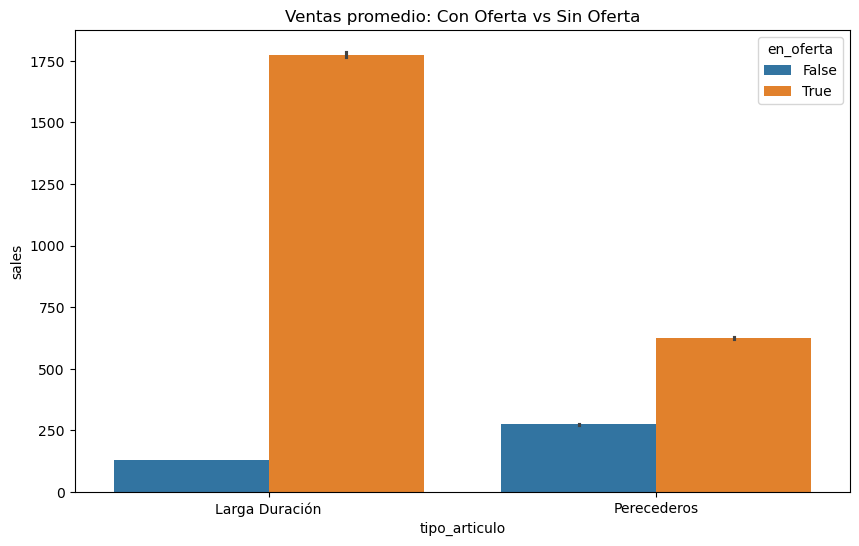

In [63]:
# 1. Definimos qué familias son "Perecederos"
# (Basado en las categorías comunes del dataset de Favorita)
perecederos = [
    'BREAD/BAKERY', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 
    'MEATS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SEAFOOD'
]

# 2. Clasificamos los productos en dos grandes grupos
df_train['tipo_articulo'] = 'Larga Duración'
df_train.loc[df_train['family'].isin(perecederos), 'tipo_articulo'] = 'Perecederos'

# 3. Creamos una columna que diga si hay promoción o no (True/False)
df_train['en_oferta'] = df_train['onpromotion'] > 0

# 4. Calculamos la media de ventas para cada grupo
resumen = df_train.groupby(['tipo_articulo', 'en_oferta'])['sales'].mean().unstack()

# 5. Calculamos cuánto suben las ventas cuando hay promoción (Uplift)
# Ventas con promoción / Ventas sin promoción
resumen['multiplicador_ventas'] = resumen[True] / resumen[False]

print("--- IMPACTO DE PROMOCIONES POR TIPO ---")
print(resumen)

# 6. Gráfico sencillo de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_train, x='tipo_articulo', y='sales', hue='en_oferta')
plt.title('Ventas promedio: Con Oferta vs Sin Oferta')
plt.show()

Podemos comprobar que el volumen de ventas de productos en promoción efectivamente es significativamente mayor respecto a los productos perecederos. Por lo cual, la hipótesis de que el volumen de ventas de los productos en promoción no es balanceada es correcta.

2.	Los días marcados como festivos (type_holiday) presentan un volumen de ventas significativamente mayor que los días laborales normales

In [64]:
laboral = ['Work Day']

# Convertir 'type_holiday' a 1 si el valor está en la lista 'laboral', de lo contrario 0
df_train['type_holiday_cod'] = df_train['type_holiday'].isin(laboral).astype(int)

C:\Users\Administrador\AppData\Local\Temp\ipykernel_29888\314399745.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='type_holiday_cod', y='sales', palette='magma')


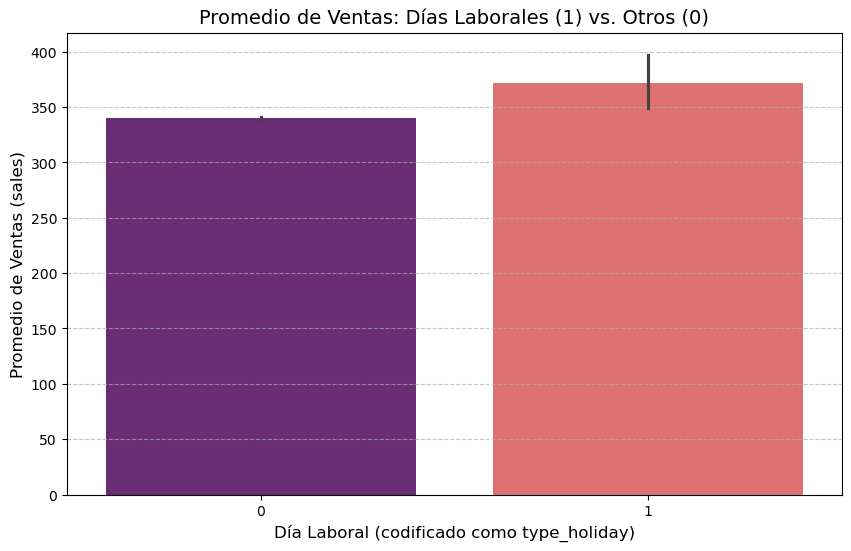

In [65]:
# Configuración del tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crear el gráfico de barras comparando la codificación del día con las ventas
# Seaborn calculará automáticamente el promedio de ventas para 0 y para 1
sns.barplot(data=df_train, x='type_holiday_cod', y='sales', palette='magma')

# Añadir títulos y etiquetas claras
plt.title('Promedio de Ventas: Días Laborales (1) vs. Otros (0)', fontsize=14)
plt.xlabel('Día Laboral (codificado como type_holiday)', fontsize=12)
plt.ylabel('Promedio de Ventas (sales)', fontsize=12)

# Añadir una cuadrícula para facilitar la lectura de la altura de las barras
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

3.	El crecimiento de las ventas en los clusters de alto rendimiento no se debe a un aumento en el número de transacciones, sino a un incremento en el valor del ticket promedio.

Clusters de alto rendimiento identificados: [2, 13, 7]


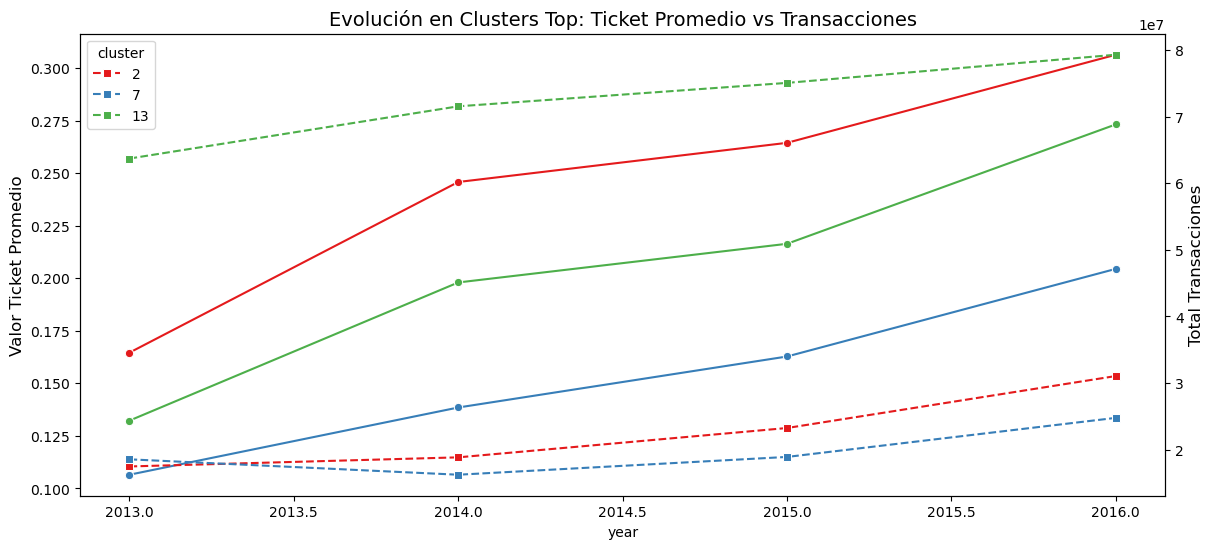

In [66]:
# 1. Agrupar datos por cluster y año para ver la evolución
df_train['year'] = df_train['date'].dt.year

# Calculamos métricas clave por cluster y año
cluster_growth = df_train.groupby(['cluster', 'year']).agg({
    'sales': 'sum',
    'transactions': 'sum'
}).reset_index()

# Calcular Ticket Promedio
cluster_growth['ticket_promedio'] = cluster_growth['sales'] / cluster_growth['transactions']

# 2. Identificar Clusters de "Alto Rendimiento" 
# (Basado en el crecimiento porcentual de ventas totales entre el primer y último año disponible)
ventas_inicio = cluster_growth[cluster_growth['year'] == cluster_growth['year'].min()].set_index('cluster')['sales']
ventas_fin = cluster_growth[cluster_growth['year'] == cluster_growth['year'].max()].set_index('cluster')['sales']
crecimiento_pct = ((ventas_fin / ventas_inicio) - 1).sort_values(ascending=False)

# Tomamos los 3 clusters que más crecieron
top_clusters = crecimiento_pct.head(3).index.tolist()
print(f"Clusters de alto rendimiento identificados: {top_clusters}")

# 3. Visualización: Comparar Evolución de Transacciones vs Ticket Promedio
fig, ax1 = plt.subplots(figsize=(14, 6))

# Filtrar solo los clusters top para el gráfico
df_top = cluster_growth[cluster_growth['cluster'].isin(top_clusters)]

# Eje 1: Ticket Promedio (Líneas sólidas)
sns.lineplot(data=df_top, x='year', y='ticket_promedio', hue='cluster', 
             marker='o', ax=ax1, palette='Set1', legend=False)
ax1.set_ylabel('Valor Ticket Promedio', fontsize=12)
ax1.set_title('Evolución en Clusters Top: Ticket Promedio vs Transacciones', fontsize=14)

# Eje 2: Transacciones (Líneas punteadas)
ax2 = ax1.twinx()
sns.lineplot(data=df_top, x='year', y='transactions', hue='cluster', 
             marker='s', ax=ax2, palette='Set1', linestyle='--')
ax2.set_ylabel('Total Transacciones', fontsize=12)

plt.show()

5.	Las ventas de categorías 'Aspiracionales' o de 'Ticket Alto' (como LIQUOR, WINE, BEER, BEAUTY y HOME AND KITCHEN) presentan un incremento superior al 25% durante los días 15 y el último día del mes, en comparación con los días valle (días 5 al 10).


Ventas promedio en Pago: 33.78
Ventas promedio en Valle: 29.23
El incremento es del: 15.56%


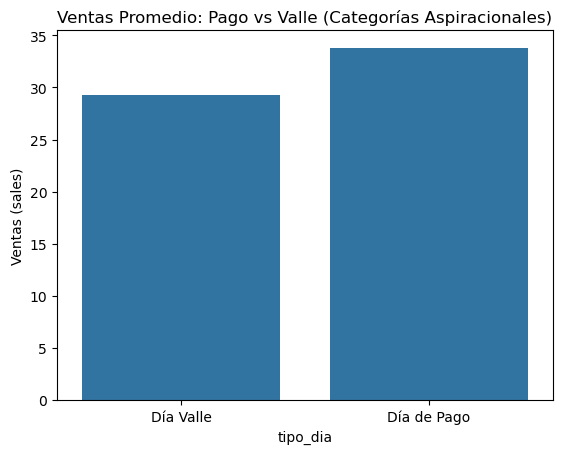

In [67]:
# 1. Definimos las familias de "Ticket Alto"
aspiracionales = ['LIQUOR,WINE,BEER', 'BEAUTY', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II']

# 2. Extraemos el día del mes y filtramos los productos aspiracionales
df_train['dia'] = df_train['date'].dt.day
df_top = df_train[df_train['family'].isin(aspiracionales)].copy()

# 3. Clasificamos los días: Pago (15 y fin de mes) vs Valle (5 al 10)
def categorizar(row):
    if row['dia'] == 15 or row['date'].is_month_end:
        return 'Día de Pago'
    if 5 <= row['dia'] <= 10:
        return 'Día Valle'
    return 'Otro'

df_top['tipo_dia'] = df_top.apply(categorizar, axis=1)

# 4. Calculamos el promedio de ventas por tipo de día
# Solo nos interesan los grupos "Día de Pago" y "Día Valle"
comparativa = df_top[df_top['tipo_dia'] != 'Otro'].groupby('tipo_dia')['sales'].mean()

# 5. Calculamos el incremento porcentual
pago = comparativa['Día de Pago']
valle = comparativa['Día Valle']
incremento = ((pago / valle) - 1) * 100

print(f"Ventas promedio en Pago: {pago:.2f}")
print(f"Ventas promedio en Valle: {valle:.2f}")
print(f"El incremento es del: {incremento:.2f}%")

# 6. Gráfico rápido de comparación
sns.barplot(x=comparativa.index, y=comparativa.values)
plt.title('Ventas Promedio: Pago vs Valle (Categorías Aspiracionales)')
plt.ylabel('Ventas (sales)')
plt.show()

5. El comportamiento de compra está más fuertemente correlacionado con el cluster de la tienda que con su ubicación geográfica exacta

C:\Users\Administrador\AppData\Local\Temp\ipykernel_29888\3022153156.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='city', y='sales', ax=axes[0], palette='magma', errorbar=('ci', 95))
C:\Users\Administrador\AppData\Local\Temp\ipykernel_29888\3022153156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='cluster', y='sales', ax=axes[1], palette='viridis', errorbar=('ci', 95))


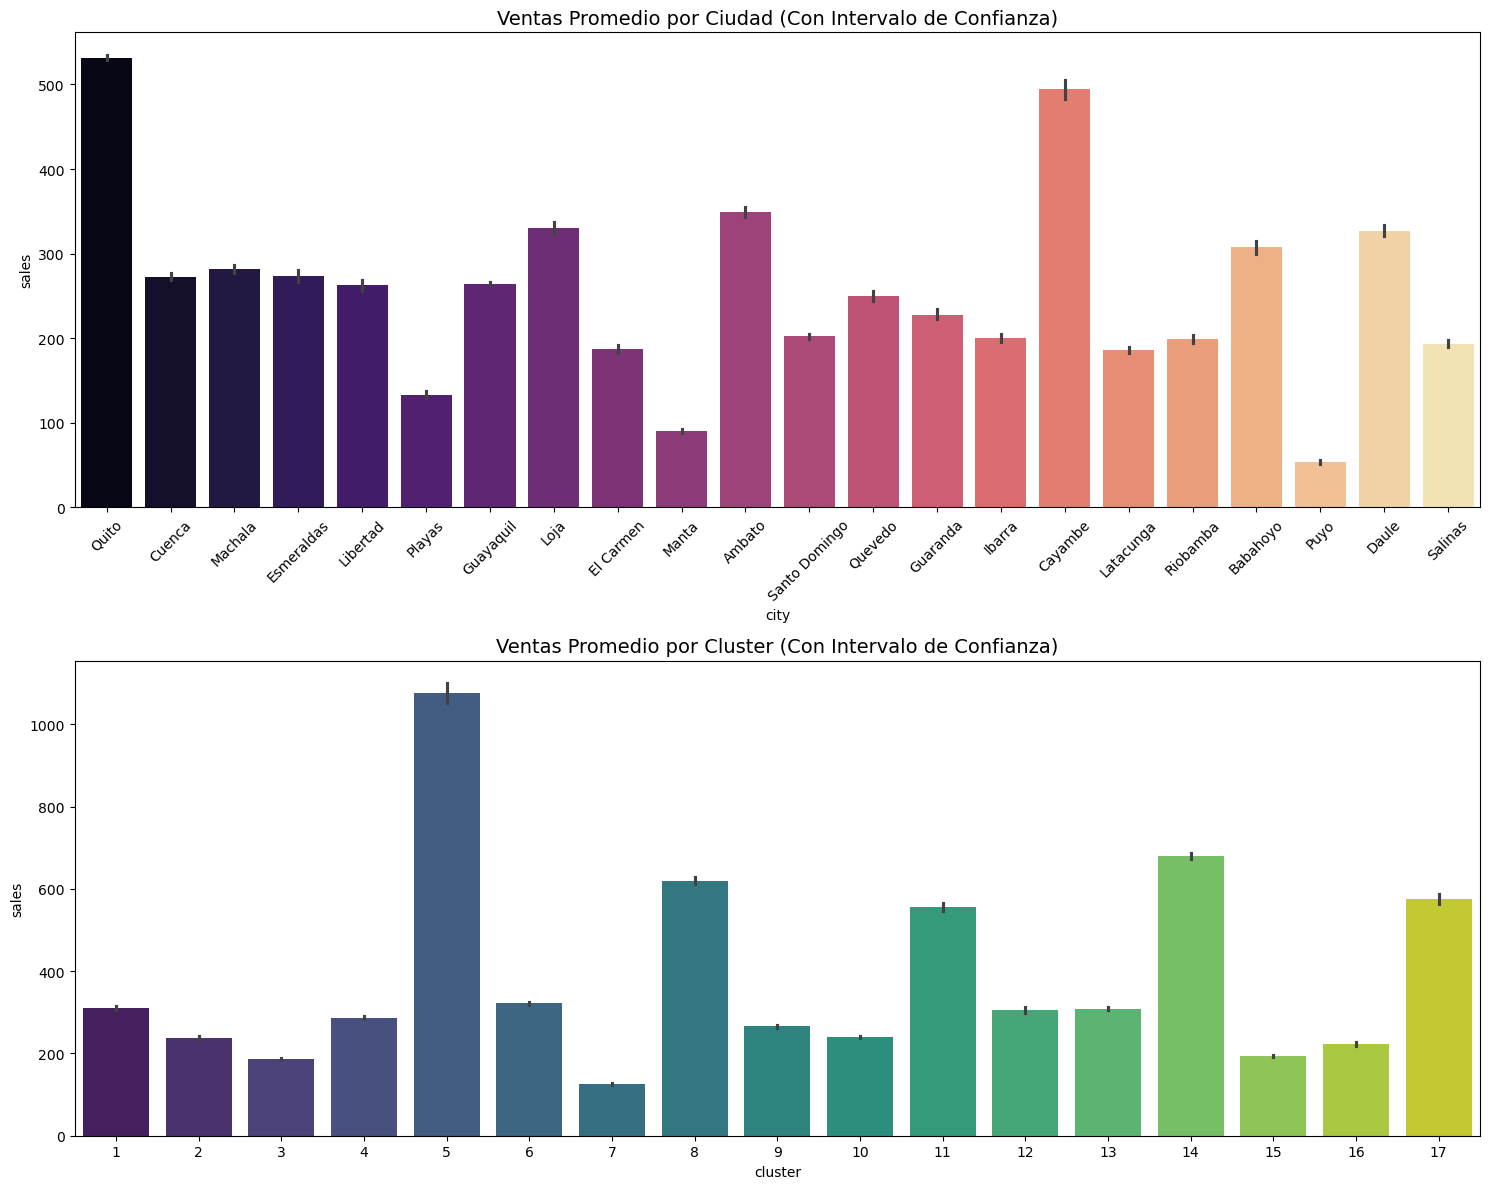

Diferencia entre el mejor y peor Cluster: 949.5745327093217
Diferencia entre la mejor y peor Ciudad: 477.50307658594045


In [73]:
# 1. Comparación de Medias: ¿Qué variable separa mejor los niveles de venta?
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Ventas promedio por Ciudad
sns.barplot(data=df_train, x='city', y='sales', ax=axes[0], palette='magma', errorbar=('ci', 95))
axes[0].set_title('Ventas Promedio por Ciudad (Con Intervalo de Confianza)', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Ventas promedio por Cluster
sns.barplot(data=df_train, x='cluster', y='sales', ax=axes[1], palette='viridis', errorbar=('ci', 95))
axes[1].set_title('Ventas Promedio por Cluster (Con Intervalo de Confianza)', fontsize=14)

plt.tight_layout()
plt.show()

# 2. El "Filtro Definitivo": Agrupación jerárquica
# Esto muestra cómo las ventas se agrupan de forma mucho más extrema por Cluster
cluster_means = df_train.groupby('cluster')['sales'].mean().sort_values(ascending=False)
city_means = df_train.groupby('city')['sales'].mean().sort_values(ascending=False)

print("Diferencia entre el mejor y peor Cluster:", cluster_means.max() - cluster_means.min())
print("Diferencia entre la mejor y peor Ciudad:", city_means.max() - city_means.min())

En la gráfica posterior vemos que las ciudades no se ve una diferencia entre ellas, esto quiere decir que muchas ciudades tienen números de ventas muy similares, por lo que no está del todo segmentado. En cambio, en el gráfico inferior, observamos que la diferencia entre clusters es mucha más grande, aqui vemos que esta variable tiene mucho más peso y puede ser mucho más útil para nuestro modelo. Finalmente, la diferencia entre el mejor y peor Cluster (949.57) es prácticamente el doble que la diferencia entre la mejor y peor Ciudad (477.50). Esto significa que el cluster tiene mucha más "fuerza" para explicar por qué una tienda vende más que otra. Por lo que, aceptamos la hipótesis, yua que el cluster captura la verdadera identidad de la tienda, mientras que la Ciudad es solo una etiqueta geográfica, es decir, mete ruido al modelo. Por lo que, seguramente sería una variable a eliminar.

6. Dada la estructura de pagos de nómina en Ecuador (comúnmente distribuida de forma bimensual los días 15 y 30/31), existe un incremento estadísticamente significativo en el volumen de ventas durante estos días y los inmediatamente posteriores.

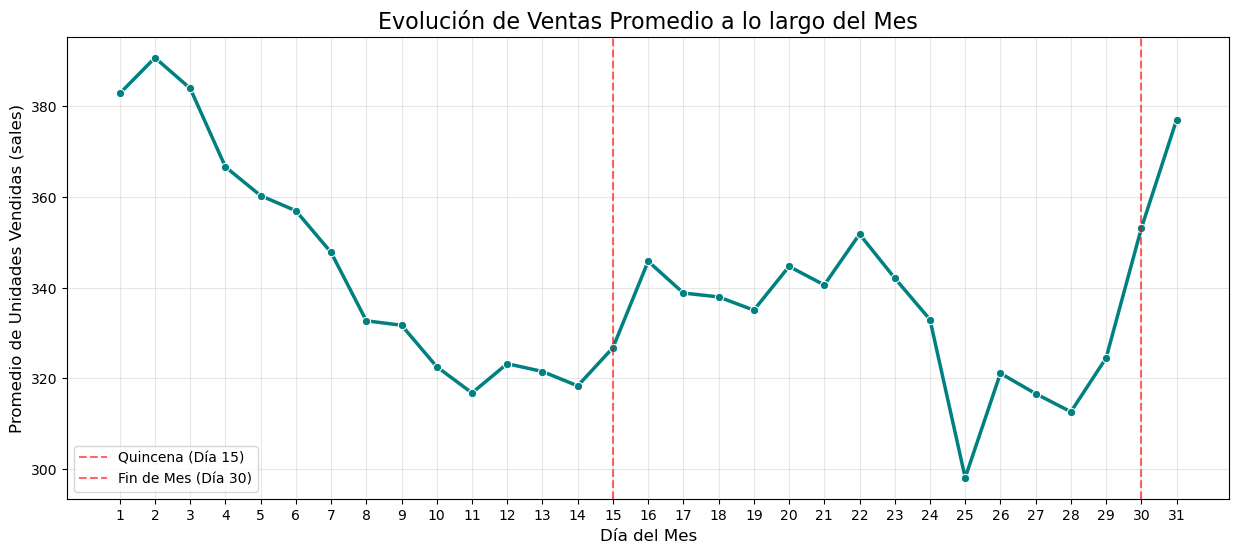

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar las ventas promedio por día del mes
# (Esto promedia el comportamiento de todos los meses de los 4 años del dataset)
ventas_por_dia = df_train.groupby('day')['sales'].mean()

# 2. Crear el gráfico de líneas
plt.figure(figsize=(15, 6))
sns.lineplot(x=ventas_por_dia.index, y=ventas_por_dia.values, marker='o', color='teal', linewidth=2.5)

# 3. Resaltar visualmente los días de pago (15 y 30)
plt.axvline(x=15, color='red', linestyle='--', alpha=0.6, label='Quincena (Día 15)')
plt.axvline(x=30, color='red', linestyle='--', alpha=0.6, label='Fin de Mes (Día 30)')

# 4. Configurar el diseño
plt.title('Evolución de Ventas Promedio a lo largo del Mes', fontsize=16)
plt.xlabel('Día del Mes', fontsize=12)
plt.ylabel('Promedio de Unidades Vendidas (sales)', fontsize=12)
plt.xticks(range(1, 32)) # Mostrar todos los números de los días
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

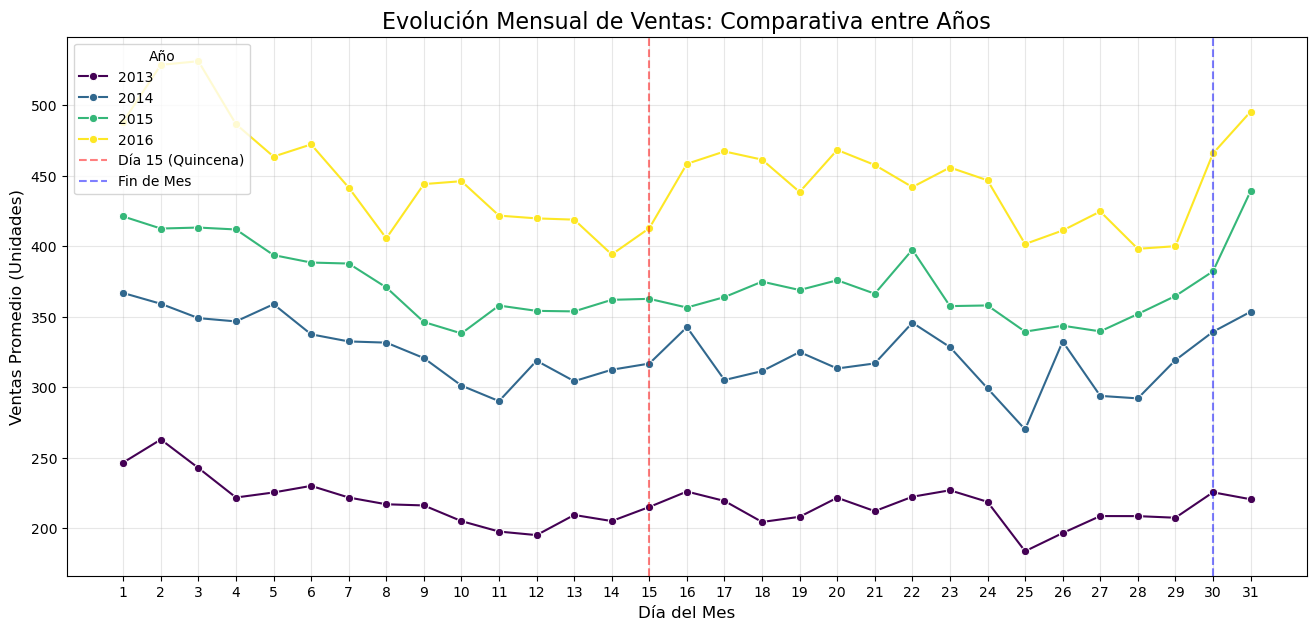

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos agrupando por año y día del mes
# Promediamos las ventas para cada día del mes individualmente por cada año
df_anual = df_train.groupby(['year', 'day'])['sales'].mean().reset_index()

# 2. Configurar el gráfico de líneas
plt.figure(figsize=(16, 7))

# Crear una línea para cada año
sns.lineplot(data=df_anual, x='day', y='sales', hue='year', palette='viridis', marker='o')

# 3. Marcar los días clave de pago (15 y 30) para todos los años
plt.axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Día 15 (Quincena)')
plt.axvline(x=30, color='blue', linestyle='--', alpha=0.5, label='Fin de Mes')

# 4. Detalles del diseño
plt.title('Evolución Mensual de Ventas: Comparativa entre Años', fontsize=16)
plt.xlabel('Día del Mes', fontsize=12)
plt.ylabel('Ventas Promedio (Unidades)', fontsize=12)
plt.xticks(range(1, 32))
plt.grid(True, alpha=0.3)
plt.legend(title='Año')

plt.show()

# Análisis Multivariable

In [54]:
# Creamos un subset del dataframe original
df_corr = df_train[numeric_cols]

# 2. Calculamos las matrices de correlación
pearson_matrix = df_corr.corr(method='pearson')
spearman_matrix = df_corr.corr(method='spearman')


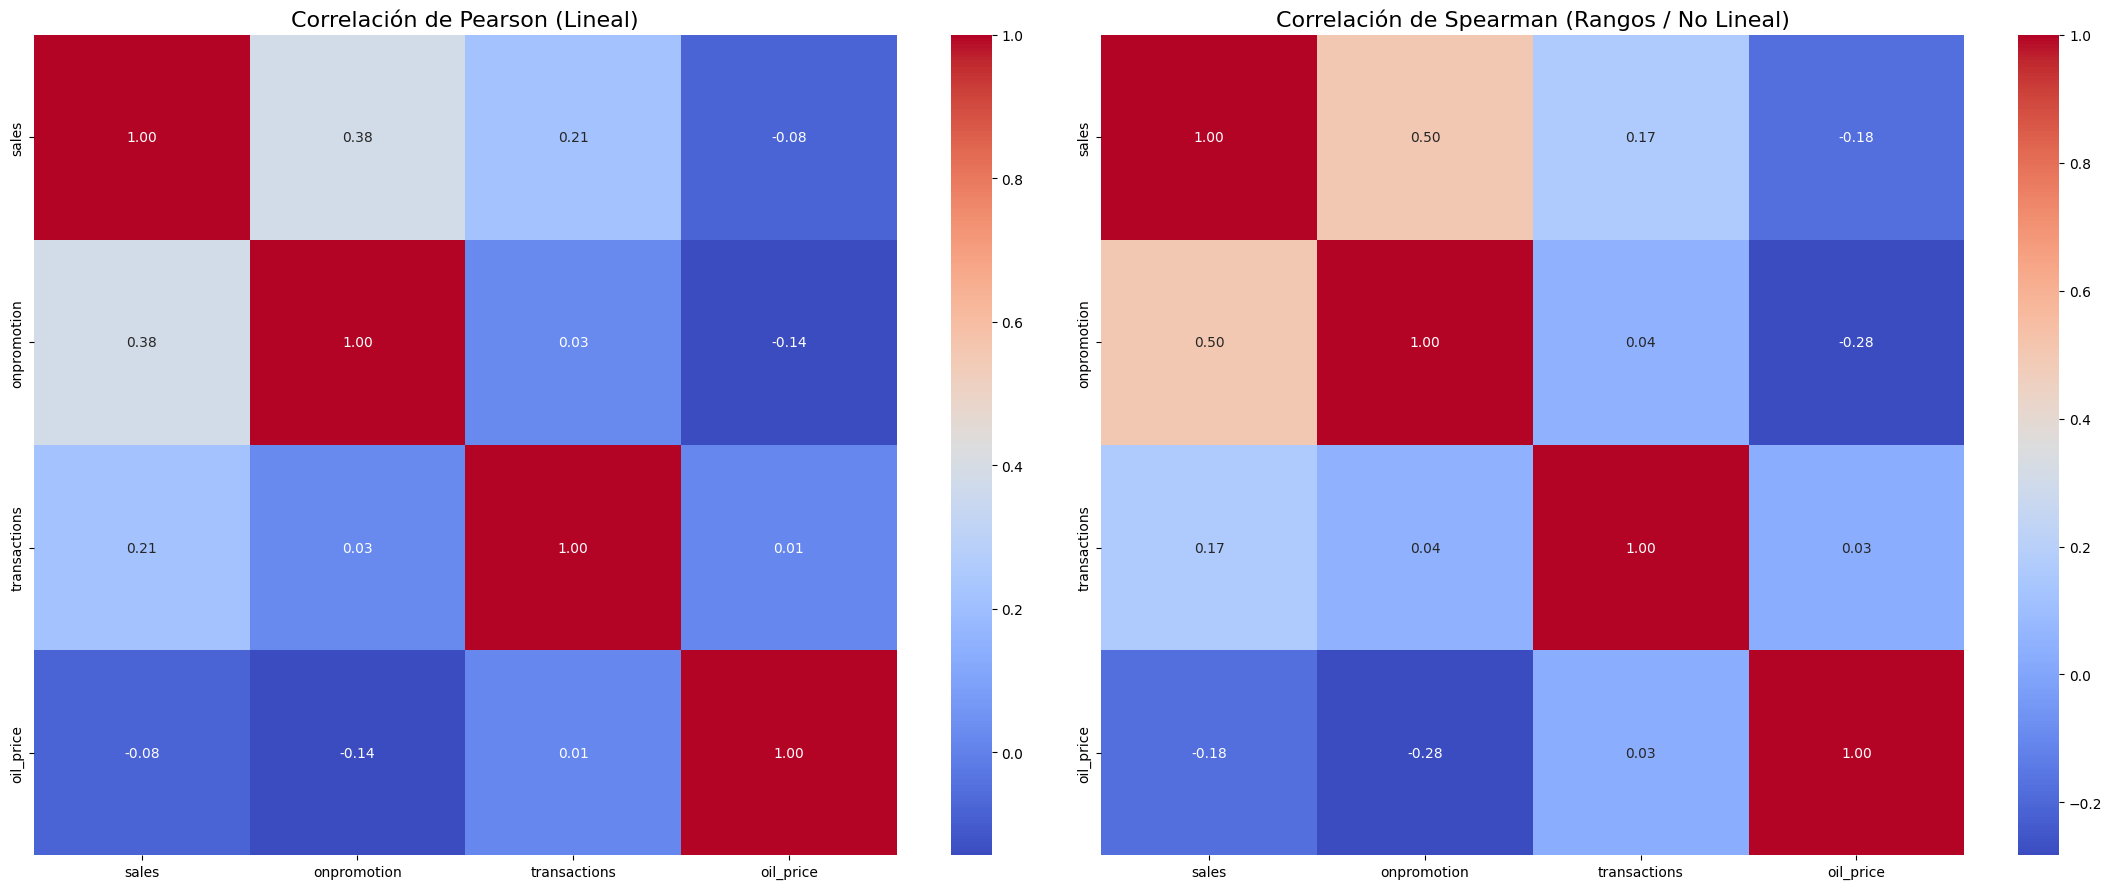

In [55]:
# 3. Configuramos la figura con dos subplots (uno al lado del otro)
fig, ax = plt.subplots(1, 2, figsize=(22, 9))

# Heatmap de Pearson
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0], cbar=True)
ax[0].set_title('Correlación de Pearson (Lineal)', fontsize=16)

# Heatmap de Spearman
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1], cbar=True)
ax[1].set_title('Correlación de Spearman (Rangos / No Lineal)', fontsize=16)

plt.tight_layout()
plt.show()

In [56]:
print("--- Correlación de Spearman con el Fraude (is_fraud) ---")
print(spearman_matrix['sales'].sort_values(ascending=False))


--- Correlación de Spearman con el Fraude (is_fraud) ---
sales           1.000000
onpromotion     0.501814
transactions    0.165605
oil_price      -0.178042
Name: sales, dtype: float64


In [57]:
print("--- Correlación de Spearman con el Fraude (is_fraud) ---")
print(pearson_matrix['sales'].sort_values(ascending=False))

--- Correlación de Spearman con el Fraude (is_fraud) ---
sales           1.000000
onpromotion     0.380458
transactions    0.214337
oil_price      -0.077777
Name: sales, dtype: float64


In [58]:
import numpy as np
from sklearn.feature_selection import mutual_info_regression

# 1. Selección robusta de numéricas
numeric_features = df_train.select_dtypes(include=[np.number]).copy()

# 2. Eliminación de la columna objetivo (Target)
numeric_features = numeric_features.drop(columns=['sales'], errors='ignore')

# 3. Tratamiento de nulos (Imputación simple para el análisis)
# Rellenamos con 0 para no perder filas en el cálculo de importancia
X = numeric_features.fillna(0)
y = df_train['sales'].fillna(0)

# 4. Cálculo de Información Mutua
print("Calculando relevancia de variables...")
mi_scores = mutual_info_regression(X, y, random_state=42)

# 5. Formateo de resultados
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("\nRanking de importancia de variables numéricas:")
print(mi_results)

Calculando relevancia de variables...

Ranking de importancia de variables numéricas:
onpromotion        0.180228
transactions       0.166133
transactions_yj    0.162620
oil_price          0.041195
dtype: float64


**Variables Categóricas**

In [59]:
resultados = []

print("--- Análisis de Chi-Cuadrado vs is_fraud ---")

for col in categoric_cols:
    # Creamos la tabla de contingencia (frecuencias cruzadas)
    contingency_table = pd.crosstab(df_train[col], df_train['sales'])
    
    # Calculamos Chi2 y el p-valor
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Interpretación
    dependiente = "SÍ (Significativa)" if p < 0.05 else "NO (Independiente)"
    
    resultados.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p-valor': f"{p:.4e}", # Formato científico para p-valores muy pequeños
        'Relación con Fraude': dependiente
    })

# 2. Mostramos los resultados en una tabla limpia
df_chi = pd.DataFrame(resultados).sort_values(by='Chi2', ascending=False)
print(df_chi.to_string(index=False))


--- Análisis de Chi-Cuadrado vs is_fraud ---
    Variable        Chi2     p-valor Relación con Fraude
      family 16677866.37  0.0000e+00  SÍ (Significativa)
 description  7011760.50  0.0000e+00  SÍ (Significativa)
     cluster  6096464.60  0.0000e+00  SÍ (Significativa)
        city  5960696.52  1.0000e+00  NO (Independiente)
       state  4153428.88  1.0000e+00  NO (Independiente)
  type_store  1454412.21  0.0000e+00  SÍ (Significativa)
 locale_name  1442770.38  1.0000e+00  NO (Independiente)
 transferred   356853.05 2.5188e-223  SÍ (Significativa)
type_holiday   355448.49  8.3886e-83  SÍ (Significativa)
      locale   129243.48  1.0000e+00  NO (Independiente)


In [60]:
def cramers_v(contingency_table):
    """ Calcula el coeficiente V de Cramer para una tabla de contingencia. """
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

resultados_v = []

print("--- Análisis de Fuerza de Asociación (V de Cramer) ---")

for col in categoric_cols:
    # Creamos la tabla de contingencia
    contingency_table = pd.crosstab(df_train[col], df_train['sales'])
    
    # Calculamos V de Cramer
    v = cramers_v(contingency_table)
    
    # Interpretación rápida de la fuerza
    if v > 0.5: fuerza = "Muy Fuerte"
    elif v > 0.3: fuerza = "Fuerte"
    elif v > 0.1: fuerza = "Moderada"
    else: fuerza = "Débil"
    
    resultados_v.append({
        'Variable': col,
        'Cramers V': round(v, 4),
        'Fuerza': fuerza
    })

# Mostramos resultados ordenados por fuerza
df_v = pd.DataFrame(resultados_v).sort_values(by='Cramers V', ascending=False)
print(df_v.to_string(index=False))

--- Análisis de Fuerza de Asociación (V de Cramer) ---
    Variable  Cramers V   Fuerza
      family     0.2688 Moderada
     cluster     0.1386 Moderada
  type_store     0.1123 Moderada
 transferred     0.1003 Moderada
type_holiday     0.0847    Débil
 description     0.0811    Débil
        city     0.0000    Débil
       state     0.0000    Débil
 locale_name     0.0000    Débil
      locale     0.0000    Débil


## Conclusiones finales